[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammedmka95/Medad-CV-Bootcamp/blob/main/Week5/week_5_backprop_mnist_cnn.ipynb)

<div dir="rtl">

# الأسبوع 5: من الانتشار الخلفي إلى الشبكات الالتفافية CNN

---
**المُعد/المؤلف:** [عامر صوان](https://linkedin.com/in/amer-sawan) و [Mohammed Tattan]() و [Mohamad Haj Fares](https://www.linkedin.com/in/mohres/)

---

في الأسابيع الماضية أتقنّا أدوات الرؤية الكلاسيكية (Canny للحواف، Gaussian للتنعيم، MOG2 للحركة)، وتعرّفنا على البرسبترون وكيف يتعلّم.

اليوم درس من ثلاث محطات، كل واحدة تبني على السابقة:

1. **نفهم كيف تتعلم الشبكة** — خوارزمية الانتشار الخلفي (Backpropagation) بأبسط صورة ممكنة: على الورق، بأرقام صغيرة نحسبها بأيدينا.
2. **نجهّز أدوات التدريب** — دالة الخسارة والمُحسّن وحلقة التدريب.
3. **نطبّق عملياً** — ندرّب شبكة تقرأ الأرقام المكتوبة بخط اليد (MNIST)، ثم نكتشف نقطة ضعفها، ونحلّها بالشبكات الالتفافية **CNN** — جوهر رؤية الحاسوب الحديثة.

---

</div>

<div dir="rtl">

## 📋 محتويات هذا الدرس

1. 🧰 **مكوّنات التدريب** — Loss, Optimizer, Training Loop
2. 🔙 **الانتشار الخلفي ببساطة** — Backpropagation by Hand
3. 🔢 **التطبيق الأول:** تصنيف الأرقام المكتوبة بخط اليد (MNIST)
4. ⚠️ **مشكلة تسطيح الصورة** — The Flattening Problem
5. ✨ **عملية الـ Convolution** — The Convolution Operation
6. 🌈 **الـ Kernels المتعددة وعمق الصورة** — Multiple Kernels & Image Depth
7. 🔗 **المسار الكامل للشبكة العصبية CNN** — Stacking CNN Layers
8. 🏊 **الـ Max Pooling**
9. 🧬 **لماذا تتفوق CNN على الشبكات العادية؟** — Inductive Biases
    - 9.1 🎯 الاتصال المحلي — Local Connectivity
    - 9.2 ↔️ التحول المتساوي — Translation Equivariance
    - 9.3 ♻️ مشاركة البارمترات — Parameter Sharing
    - 9.4 🐱 ثبات الترجمة — Translation Invariance
    - 9.5 🏔️ التسلسل الهرمي للميزات — Hierarchical Features
10. 📊 **مقارنة CNN مقابل Fully Connected**
11. 🏆 **التطبيق الثاني:** CNN على MNIST — الإثبات العملي
12. 📚 مصادر للاستزادة

</div>

<div dir="rtl">

---
## ⚙️ التجهيز: تثبيت واستيراد المكتبات

شغّلوا الخليتين التاليتين أولاً — سنحتاجهما في كل أجزاء الدرس.

</div>

In [4]:
# ⚠️ تنبيه: شغّل هذه الخلية أولاً!
# مكتبات لعرض النصوص العربية بشكل صحيح داخل الرسوم البيانية

!pip install arabic-reshaper python-bidi -q

print("✅ تم تثبيت المكتبات بنجاح!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 2.3 MB/s eta 0:00:00
✅ تم تثبيت المكتبات بنجاح!


In [5]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import arabic_reshaper
from bidi.algorithm import get_display

# دالة مساعدة: تجهّز أي نص عربي ليظهر صحيحاً في matplotlib
def ar(text):
    return get_display(arabic_reshaper.reshape(text))

torch.manual_seed(42)  # لنحصل جميعاً على نفس النتائج (تذكرون قصة البذرة من الدرس الماضي؟)
print("✅ تم تحميل جميع المكتبات بنجاح! | PyTorch:", torch.__version__)

✅ تم تحميل جميع المكتبات بنجاح! | PyTorch: 2.11.0+cpu


<div dir="rtl">

# 🔄 مراجعة سريعة | من الخرج العشوائي إلى دالة التكلفة (Cost Function)

قبل أن ننتقل إلى المكوّنات البرمجية والتطبيق العملي، دعونا نقوم بمراجعة سريعة ومهمة تبسّط لنا كيف تقيس الشبكة العصبية مقدار "فشلها" أو "نجاحها" أثناء عملية التعلم، معتمدين على مثالنا الأساسي في هذا التدريب: **تصنيف الأرقام المكتوبة بخط اليد (0-9) من مجموعة بيانات MNIST**.

تخيل أننا مررنا للشبكة صورة تحتوي على الرقم **7**. كيف تبدأ العملية من الصفر؟

### 1. الخرج العشوائي مقابل الحقيقة الأرضية (One-Hot Encoding)
في اللحظات الأولى من التدريب، تكون أوزان الشبكة العصبية (Weights) غير مدربة وعشوائية تماماً. عندما تدخل صورة الرقم 7، ستعالجها الشبكة وتُخرج لنا في النهاية **10 قيم متوقعة** (قيمة أو درجة لكل رقم من 0 إلى 9). وبسبب العشوائية البحتة في البداية، ستكون هذه القيم عبارة عن أرقام مبعثرة لا معنى لها، ولا تدل على الرقم الحقيقي بأي شكل.

على الجانب الآخر، نحن نملك الجواب الصحيح والنهائي الذي نريد من الشبكة أن تصل إليه (الحقيقة الأرضية أو Ground Truth). في مسائل التصنيف الرقمي مثل MNIST، لا نكتفي بإخبار الشبكة أن الجواب هو "7"، بل نمثّل ذلك بصيغة رياضية على شكل متجه (Vector) يحتوي على **10 قيم** أيضاً. هذا المتجه تكون جميع قيمه **أصفاراً** باستثناء خانة واحدة فقط (وهي الخانة المقابلة للرقم الصحيح 7) حيث تأخذ القيمة **1** تماماً. هذه الطريقة في التمثيل تُعرف بـ **الترميز الأحادي (One-Hot Encoding)**.

الفارق المباشر بين ما توقعته الشبكة في كل خانة من الخانات العشر وبين ما كان يجب أن تتوقعه (الأصفار والواحد) هو ما نسميه **الخطأ (Error)** على مستوى كل فئة أو خانة.

![cost function](https://i.ibb.co/jks9VRMX/Screenshot-2026-07-17-171819.png)

### 2. التدرج الرياضي: كيف ننتقل من الـ Loss إلى الـ Cost؟

حتى نصل إلى مؤشر رقمي حقيقي وصالح للتدريب والاشتقاق، نمر بمرحلتين أساسيتين:

* **الخسارة (Loss):** الشبكة لن تنظر إلى الأخطاء العشرة المتفرقة بشكل منفصل؛ بل تريد رقماً واحداً يلخص الحكاية. لذلك، نقوم بحساب الفارق (أو مجموع مربعات الفروق) بين متجه التوقعات العشوائي بالكامل ومتجه الجواب الصحيح **لصورة واحدة فقط**. الرقم المفرد الناتج من هذه العملية يلخص لنا مدى سوء (أو جودة) توقع الشبكة لهذه الصورة المحددة. هذا الرقم هو **الـ Loss**.

* **دالة التكلفة (Cost Function):** لكننا بالطبع لا ندرب الشبكة لتتعرف على صورة واحدة؛ لدينا في مجموعة MNIST آلاف الصور المخصصة للتدريب. إذا قمنا بحساب الـ Loss لكل صورة تمر بها الشبكة على حدة، ثم قمنا بجمع كل هذه الخسارات وحساب **متوسطها الإجمالي على جميع حالات وأمثلة التدريب**، سنحصل على الرقم النهائي الأهم. هذا المتوسط العام الذي يمثل حصيلة أداء الشبكة عبر كامل البيانات هو ما نسميه **دالة التكلفة (Cost Function)**.

**باختصار شديد:** الـ **Loss** هو فاتورة الخطأ لـ **مثال واحد فقط**، بينما الـ **Cost** هو الفاتورة الإجمالية المتراكمة لـ **كل أمثلة التدريب** في النموذج. وهدفنا الأساسي الذي سنتعاون فيه مع "المُحسّن" (Optimizer) عبر خوارزمية الانتشار الخلفي (Backpropagation) هو دفع قيمة هذا الـ Cost لتصبح أقرب ما يمكن إلى الصفر.


![cost function2](https://i.ibb.co/cc2qfLRk/Screenshot-2026-07-17-171914.png)


<div dir="rtl">

## 🧰 1. مكوّنات التدريب | Loss, Optimizer, Training Loop

عرفنا في الفقرات السابقة كيف نحسب التدرّجات رياضياً وعملياً. لكن لتدريب شبكة عصبية حقيقية قادرة على التعلم الذاتي، لا نكتفي بحساب التدرج فقط؛ بل نحتاج إلى منظومة متكاملة تتكون من **ثلاثة مكوّنات أساسية** تعمل معاً في حلقة مستمرة (Training Loop):

$$\underbrace{\text{دالة الخسارة}}_{\text{أديش غلطانين؟}} \longrightarrow \underbrace{\text{Backpropagation}}_{\text{مين المسؤول؟}} \longrightarrow \underbrace{\text{المُحسّن}}_{\text{عدّل الأوزان}}$$

---

### 📌 جدول المصطلحات الأساسية (Glossary)
قبل الغوص في التفاصيل العميقة، دعنا نتفق على معاني الكلمات والمصطلحات التي ستتكرر معنا طوال هذا الدليل:

| المصطلح بالإنجليزية | المصطلح بالعربية | المفهوم بعبارة بسيطة |
| :--- | :--- | :--- |
| **Error** | الخطأ الخام | الفارق المباشر والأساسي بين القيمة التي توقعتها الشبكة والقيمة الحقيقية لخانة واحدة. |
| **Loss** | الخسارة | دالة رياضية تحوّل جميع أخطاء الشبكة في **صورة واحدة (مثال واحد)** إلى رقم مفرد يلخص مدى سوء التوقع. |
| **Cost** | التكلفة | متوسط الخسارات (Losses) لـ **جميع صور التدريب** في قاعدة البيانات، وهو المؤشر النهائي لذكاء النموذج. |
| **Loss Function** | دالة الخسارة | الصيغة الرياضية التي نختارها بحسب نوع المسألة (تصنيف أم انحدار) لتحويل الأخطاء إلى أرقام قابلة للاشتقاق. |
| **MSE** | متوسط مربعات الخطأ | دالة خسارة شهيرة تُستخدم عندما نريد توقّع قيم مستمرة (رقم حقيقي كالسعر أو الطول). |
| **Cross-Entropy** | الإنتروبيا المتقاطعة | دالة الخسارة المثالية لمسائل التصنيف (مثل MNIST) لأنها تعاقب الشبكة بشدة إذا وثقت بجواب خاطئ. |
| **One-Hot Encoding** | الترميز الأحادي | تمثيل الجواب الصحيح على شكل متجه مليء بالأصفار، ويحتوي على الرقم 1 في خانة الإجابة الصحيحة فقط. |

---


<div dir="rtl">

### 1.1.1 التدرج المفاهيمي: ما الفرق الدقيق بين "الخطأ" و"الخسارة" و"التكلفة"؟

في الأحاديث العامة حول الذكاء الاصطناعي، تُستخدم هذه الكلمات الثلاث كمرادفات لشيء واحد. لكن في هندسة الشبكات العصبية، الفروق بينها هي التي تبني الدارة الرياضية للتعلم.

#### 🤔 أولاً: الخطأ الخام (Error)
الخطأ هو ببساطة الحساب المباشر والأولي للفارق:
$$\text{الخطأ} = y - \hat{y}$$

حيث $y$ هو الجواب الحقيقي، و $\hat{y}$ هو توقع الشبكة.

* **مثال تطبيقي من MNIST:**
لو أدخلنا صورة للرقم **7** إلى الشبكة. الشبكة ستُخرج لنا 10 قيم (احتمالات لكل رقم من 0 إلى 9). لنفرض أن الشبكة توقعت أن احتمال كون الصورة للرقم 7 هو $0.15$ فقط (بينما الجواب الحقيقي الصحيح هو $1.0$).
الخطأ الخام في خانة الرقم 7 هنا هو: $1.0 - 0.15 = 0.85$. هذا مجرد قياس موضعي لخانة واحدة، ولا يصلح وحده لقيادة عملية التعلم لأنه لا ينظر إلى الصورة الكاملة للخرج.

#### 📉 ثانياً: الخسارة (Loss)
الخسارة هي دالة **نحن نختارها** بعناية لنأخذ كل الأخطاء المتفرقة الناتجة عن **مثال واحد فقط (صورة واحدة)** ونلخصها في **رقم مفرد واحد موجّب**.

لماذا نحتاج هذا الرقم المفرد؟ لأن خوارزمية الانتشار الخلفي (Backpropagation) تحتاج إلى "مصبّ" أو نقطة نهاية واحدة تبدأ منها رحلة العودة للاشتقاق وتوزيع المسؤولية على الأوزان.

> **💡 تشبيه تقريبي:** الخطأ هو "كم درجة خسرتها في السؤال الأول، وكم خسرت في السؤال الثاني بالامتحان". أما الخسارة فهي "المعدل النهائي لورقتك الامتحانية". طريقة موحدة لتقييم أدائك في هذا الاختبار المحدد.

#### 📊 ثالثاً: التكلفة (Cost)
عندما نقوم بحساب الخسارة (Loss) لكل صورة على حدة، ثم نجمع هذه الخسارات لكل الصور الموجودة في حزمة التدريب (Batch) أو كامل قاعدة البيانات، ونأخذ **المتوسط الحسابي** لها، فإننا نحصل على **التكلفة (Cost)**.

إذاً التكلفة هي المؤشر العام والنهائي لمستوى النموذج:
- التكلفة عالية؟ النموذج سيء بشكل عام على معظم الصور.
- التكلفة منخفضة؟ النموذج بدأ يفهم الأنماط وينجح في تصنيف أغلب الصور.


<div dir="rtl">

### 1.1.2 كيف نختار دالة الخسارة المناسبة لمشروعنا؟

تختلف دالة الخسارة باختلاف طبيعة المخرجات التي نريد من الذكاء الاصطناعي توقّعها. لدينا عائلتان أساسيتان من المسائل:

#### 1️⃣ للمسائل الانحدارية (Regression) - توقع قيمة مستمرة: MSE
إذا كان مطلوباً من الشبكة توقع رقم حقيقي (مثل سعر منزل، درجة الحرارة غداً)، فإن الدالة القياسية هي **متوسط مربعات الخطأ (Mean Squared Error)**:

$$L = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

**لماذا نربّع الفروق دائماً في دالة MSE؟**
1. **إلغاء الإشارات السالبة:** لو أخطأت الشبكة في عينة بـ $+5$ وفي عينة أخرى بـ $-5$، وجمعنا الأخطاء مباشرة، سيكون الناتج $0$! وكأن الشبكة عبقرية ولم تخطئ أبداً. التربيع يحوّل كل الأخطاء إلى قيم موجبة ليتراكم حجم التقصير.
2. **معاقبة الأخطاء الكبيرة بشدة:** تربيع الخطأ الصغير (مثل $0.5$) يجعله أصغر ($0.25$)، بينما تربيع الخطأ الكبير (مثل $10$) يجعله ضخماً جداً ($100$). هذا يجبر الشبكة أثناء التدريب على التركيز على إصلاح الأخطاء الفادحة أولاً.
3. **النعومة الرياضية:** التربيع يعطينا دالة منحنية وملساء (Smooth)، وهو شرط أساسي لتعمل خوارزمية الاشتقاق والانتشار الخلفي بكفاءة دون قفزات حادة.

#### 2️⃣ للمسائل التصنيفية (Classification) - اختيار فئة: Cross-Entropy
مسألتنا الحالية في نوت بوك MNIST هي مسألة **تصنيف** (لدينا 10 فئات محتملة من 0 إلى 9)، وهنا لا يصلح استخدام MSE تماماً. الشبكة ستُخرج 10 درجات، نمررها على دالة مثل *Softmax* لتحويلها إلى احتمالات (أرقام بين 0 و 1 ومجموعها يساوي 1).

دالة **الإنتروبيا المتقاطعة (Cross-Entropy Loss)** تقيس كفاءة هذه الاحتمالات عبر الصيغة التالية للفئة الصحيحة:

$$L = -\log\big(p_{\text{الفئة الصحيحة}}\big)$$

حيث $p$ هو الاحتمال الذي توقعته الشبكة للفئة الحقيقية.

**كيف تعمل هذه الدالة السحرية؟ لنراقب سلوك اللوغاريتم معاً:**
- **الشبكة ذكية وواثقة:** لو كانت الصورة للرقم 7، وقالت الشبكة إن احتمال كونه 7 هو $0.99$ (قريب جداً من 1). بالتعويض: $-\log(0.99) \approx 0$. الخسارة تكاد تنعدم ✅، والشبكة تتلقى مكافأة بالاستقرار.
- **الشبكة واثقة ولكن في الاتجاه الخاطئ (كارثة):** لو كانت الصورة للرقم 7، لكن الشبكة صبّت كل ثقتها في الرقم 3، وأعطت للرقم 7 احتمالاً ضئيلاً جداً مثل $0.001$. بالتعويض: $-\log(0.001) \approx 6.9$. هذه خسارة ضخمة جداً! 💥

**الفكرة الجوهرية:** دالة Cross-Entropy لا تعاقب الخطأ لمجرد الخطأ، بل **تعاقب الثقة العمياء في الجواب الخاطئ** عقاباً شديداً وقاسياً، مما يجبر أوزان الشبكة العصبية على إعادة الهيكلة بسرعة لتجنب هذه الثقة القاتلة.


<div dir="rtl">

### 1.2 المُحسّن (Optimizer) — قلب التعلّم ❤️

الانتشار الخلفي أعطانا $\frac{\partial L}{\partial w}$ لكل وزن — أي "لو زدت هذا الوزن قليلاً، هل تزيد الخسارة أم تنقص؟". المُحسّن هو الذي **يستخدم هذا الجواب ليعدّل الأوزان فعلياً**:

$$w \leftarrow w - \eta \cdot \frac{\partial L}{\partial w}$$

أي: حرّك كل وزن **عكس اتجاه** ازدياد الخسارة، بخطوة حجمها $\eta$ (**معدل التعلم — Learning Rate**). هذا هو **الانحدار التدرّجي (Gradient Descent)**.

#### 🕰️ قارنوا مع برسبترون 1958 الذي درّبناه بأيدينا!

| | برسبترون 1958 | الانحدار التدرّجي (اليوم) |
|---|---|---|
| **الفكرة الجوهرية** | الخطأ $(y-\hat{y})$ يوجّه تعديل الوزن | الخطأ (عبر المشتقة) يوجّه تعديل الوزن |
| **كيف يصل الخطأ للوزن؟** | مباشرة — الوزن متصل بالمخرج | عبر **backpropagation** — قاعدة السلسلة توصل "اللوم" حتى للطبقات المخفية |
| **عدد الطبقات الممكن** | طبقة واحدة فقط ❌ | أي عمق ✅ |

**الاستنتاج المهم:** الفكرة **نفسها لم تتغير منذ 1958** — "غلطت؟ عدّل الأوزان باتجاه يصغّر الغلط". الذي تغيّر هو أننا صرنا نعرف كيف **نوصل إشارة الخطأ إلى الطبقات المخفية** (backprop)، وهذا ما فتح باب التعلم العميق كله.

> أشهر المُحسّنات: **SGD** (الانحدار التدرّجي الكلاسيكي) و **Adam** (نسخة أذكى تكيّف حجم الخطوة لكل وزن تلقائياً — سنستخدمها اليوم).

#### لكن... ما أهمية حجم الخطوة $\eta$؟

تخيلوا كرة تتدحرج في وادٍ وتريد الوصول للقاع (أقل خسارة). حجم الخطوة يحدد كل شيء — لنرَ ذلك بأعيننا:

</div>

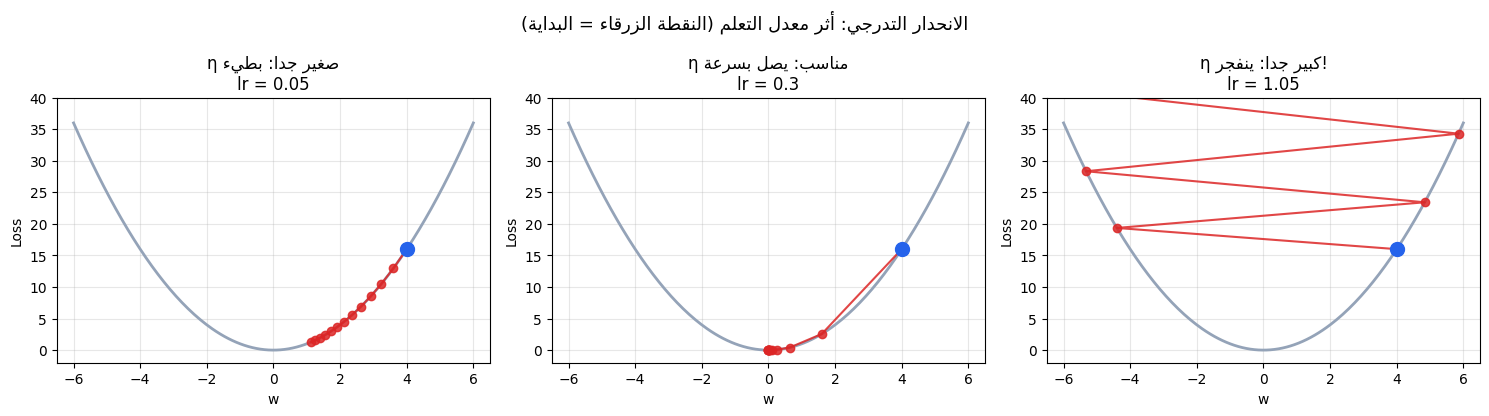

In [ ]:
# 🎢 تجربة: نفس الوادي، ثلاث خطوات مختلفة
# الخسارة هنا دالة بسيطة L(w) = w²  — القاع عند w = 0
# قاعدة التحديث: w ← w - lr · dL/dw  حيث dL/dw = 2w

def gradient_descent_path(lr, w0=4.0, steps=12):
    path = [w0]
    w = w0
    for _ in range(steps):
        w = w - lr * (2 * w)   # قاعدة التحديث نفسها التي كتبناها بالمعادلة
        path.append(w)
    return path

w_axis = np.linspace(-6, 6, 200)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
experiments = [
    (0.05, ar('η صغير جداً: بطيء')),
    (0.30, ar('η مناسب: يصل بسرعة')),
    (1.05, ar('η كبير جداً: ينفجر!')),
]

for axi, (lr, title) in zip(axes, experiments):
    path = np.array(gradient_descent_path(lr))
    axi.plot(w_axis, w_axis**2, color='#94a3b8', lw=2)
    axi.plot(path, path**2, 'o-', color='#dc2626', markersize=6, lw=1.5, alpha=0.85)
    axi.plot(path[0], path[0]**2, 'o', color='#2563eb', markersize=10)  # نقطة البداية
    axi.set_title(f'{title}\nlr = {lr}')
    axi.set_xlabel('w'); axi.set_ylabel('Loss')
    axi.set_xlim(-6.5, 6.5); axi.set_ylim(-2, 40)
    axi.grid(alpha=0.3)

plt.suptitle(ar('الانحدار التدرّجي: أثر معدل التعلم (النقطة الزرقاء = البداية)'), fontsize=13)
plt.tight_layout()
plt.show()

<div dir="rtl">

### 1.3 حلقة التدريب (Training Loop)

نجمع كل شيء الآن. كل دورة (Epoch) فيها **4 خطوات ثابتة** — احفظوها، هي نفسها في كل مشروع PyTorch ستكتبونه في حياتكم:

| الخطوة | الكود | المعنى |
|--------|-------|--------|
| 1. تصفير التدرجات | `optimizer.zero_grad()` | امسح مشتقات الدورة السابقة (PyTorch يجمعها تراكمياً) |
| 2. التمرير الأمامي | `y_pred = model(X)` | الشبكة تتوقع — كالتمرير الأخضر في دارتنا |
| 3. الانتشار العكسي | `loss.backward()` | احسب $\partial L / \partial w$ لكل وزن — كالتمرير الأحمر في دارتنا |
| 4. التحديث | `optimizer.step()` | **هنا يعمل المُحسّن**: عدّل كل الأوزان |

جاهزون؟ حان وقت التطبيق الحقيقي. 🚀

</div>

<div dir="rtl">

---

## 🔙 2. الانتشار الخلفي ببساطة | Backpropagation by Hand

### السؤال الذي يقوم عليه التعلم العميق كله

عندما تُخطئ الشبكة العصبية في تنبؤها، لدينا آلاف (أو ملايين) الأوزان. السؤال:

> **أي وزن هو "المسؤول" عن الخطأ؟ وبأي مقدار؟ وفي أي اتجاه نعدّله؟**

في درس XOR السابق تحايلنا على هذا السؤال: أعطينا كل عصبون مخفي هدفاً فرعياً بأيدينا (OR و NAND). لكن هذا غشّ — في مشاكل العالم الحقيقي لا نعرف ما الذي يجب أن تتعلمه الطبقات المخفية!

الجواب الحقيقي هو خوارزمية **الانتشار الخلفي (Backpropagation)**: طريقة لحساب **مشتقة الخرج بالنسبة لكل مدخل** عبر تطبيق **قاعدة السلسلة (Chain Rule)** بشكل متكرر، من الخرج رجوعاً حتى المدخلات.

نتخيل أي معادلة كأنها **دارة كهربائية (Circuit)** من بوابات بسيطة، ونحسب كل شيء **يدوياً بأرقام صغيرة**.

</div>

<div dir="rtl">

### 2.1 المشتقة = الحساسية

قبل الدارة، نحتاج فكرة واحدة فقط: **المشتقة تخبرنا بمدى حساسية الخرج لتغيّر صغير في المدخل.**

$$\frac{df(x)}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

**مثال:** لو $f(x,y) = x \cdot y$ مع $x=4,\ y=-3$ فإن $f = -12$، والمشتقة $\frac{\partial f}{\partial x} = y = -3$.

المعنى: لو زدنا $x$ بمقدار صغير جداً $h$، فإن $f$ **ستنقص** (الإشارة سالبة) بمقدار $3h$ (ثلاثة أضعاف).

وهذه مشتقات البوابات الثلاث التي سنستخدمها طوال الدرس — احفظوها، فهي "جدول الضرب" الخاص بالتعلم العميق:

<table dir="rtl" style="margin:12px auto; border-collapse:collapse; text-align:center; font-size:1.02em;">
  <thead>
    <tr style="border-bottom:2px solid rgba(128,128,128,.55);">
      <th style="padding:10px 16px;">البوابة</th>
      <th style="padding:10px 22px;">المعادلة</th>
      <th style="padding:10px 22px; white-space:nowrap;"><span dir="ltr"><i>∂f / ∂x</i></span></th>
      <th style="padding:10px 22px; white-space:nowrap;"><span dir="ltr"><i>∂f / ∂y</i></span></th>
      <th style="padding:10px 16px;">بالكلمات</th>
    </tr>
  </thead>
  <tbody>
    <tr style="border-bottom:1px solid rgba(128,128,128,.3);">
      <td style="padding:10px 16px;"><b>جمع</b></td>
      <td style="padding:10px 22px; white-space:nowrap;"><span dir="ltr"><i>f</i> = <i>x</i> + <i>y</i></span></td>
      <td style="padding:10px 22px;">1</td>
      <td style="padding:10px 22px;">1</td>
      <td style="padding:10px 16px;">حساسة للمدخلين بالتساوي</td>
    </tr>
    <tr style="border-bottom:1px solid rgba(128,128,128,.3);">
      <td style="padding:10px 16px;"><b>ضرب</b></td>
      <td style="padding:10px 22px; white-space:nowrap;"><span dir="ltr"><i>f</i> = <i>x</i> · <i>y</i></span></td>
      <td style="padding:10px 22px;"><i>y</i></td>
      <td style="padding:10px 22px;"><i>x</i></td>
      <td style="padding:10px 16px;">مشتقة كل مدخل = <b>المدخل الآخر</b> (تبديل!)</td>
    </tr>
    <tr>
      <td style="padding:10px 16px;"><b>أعظم</b></td>
      <td style="padding:10px 22px; white-space:nowrap;"><span dir="ltr"><i>f</i> = max(<i>x</i>, <i>y</i>)</span></td>
      <td style="padding:10px 22px; white-space:nowrap;">1 إذا <span dir="ltr"><i>x</i> ≥ <i>y</i></span> وإلا 0</td>
      <td style="padding:10px 22px; white-space:nowrap;">1 إذا <span dir="ltr"><i>y</i> ≥ <i>x</i></span> وإلا 0</td>
      <td style="padding:10px 16px;">حساسة فقط للمدخل الفائز</td>
    </tr>
  </tbody>
</table>

</div>

<div dir="rtl">

### 2.2 المثال الرئيسي: دارة من بوابتين

خذوا المعادلة:

$$f(x, y, z) = (x + y) \cdot z \qquad \text{مع} \quad x = -2,\ y = 5,\ z = -4$$

الحيلة الذهبية: **نفكّكها إلى بوابات بسيطة** نعرف مشتقة كل واحدة منها:

$$q = x + y \qquad \text{ثم} \qquad f = q \cdot z$$

**التمرير الأمامي (Forward Pass):** نحسب من المدخلات إلى الخرج:
$$q = -2 + 5 = 3 \qquad \Rightarrow \qquad f = 3 \times (-4) = -12$$

**التمرير الخلفي (Backward Pass):** نريد $\frac{\partial f}{\partial x}$، لكن $x$ لا يصل إلى $f$ مباشرة — بل عبر $q$. هنا تأتي **قاعدة السلسلة**:

$$\frac{\partial f}{\partial x} = \frac{\partial f}{\partial q} \cdot \frac{\partial q}{\partial x}$$

أي: **نضرب التدرج القادم من الأمام في التدرج المحلي للبوابة.** عملياً هو مجرد ضرب رقمين!

جرّبوا الأداة التفاعلية التالية — تتبّعوا التدرجات خطوة بخطوة وهي "تتدفق" من الخرج رجوعاً إلى المدخلات:

![gradant](https://i.ibb.co/RGYCMX47/Screenshot-2026-07-17-212047.png)

</div>

In [6]:
from IPython.display import HTML
from base64 import b64decode
bp_circuit_encoded = "PHN0eWxlPgogICAgLmZ2IHsgZmlsbDogIzRhZGU4MDsgZm9udC13ZWlnaHQ6IGJvbGQ7IGZvbnQtc2l6ZTogMTVweDsgfQogICAgLmd2IHsgZmlsbDogI2Y4NzE3MTsgZm9udC13ZWlnaHQ6IGJvbGQ7IGZvbnQtc2l6ZTogMTVweDsgfQogICAgLnZsYmwgeyBmaWxsOiAjOTNjNWZkOyBmb250LXdlaWdodDogYm9sZDsgZm9udC1zaXplOiAxNnB4OyB9CiAgICAud2lyZSB7IHN0cm9rZTogIzQ3NTU2OTsgc3Ryb2tlLXdpZHRoOiAyLjU7IGZpbGw6IG5vbmU7IH0KICAgIC5nYXRlIHsgZmlsbDogIzFlMjkzYjsgc3Ryb2tlOiAjNjQ3NDhiOyBzdHJva2Utd2lkdGg6IDIuNTsgfQogICAgLmdhdGUuYWN0aXZlIHsgc3Ryb2tlOiAjYTc4YmZhOyBzdHJva2Utd2lkdGg6IDQ7IGZpbHRlcjogZHJvcC1zaGFkb3coMCAwIDhweCAjYTc4YmZhKTsgfQogICAgLmd0eHQgeyBmaWxsOiAjZTJlOGYwOyBmb250LXNpemU6IDI0cHg7IGZvbnQtd2VpZ2h0OiBib2xkOyB0ZXh0LWFuY2hvcjogbWlkZGxlOyBkb21pbmFudC1iYXNlbGluZTogY2VudHJhbDsgfQogICAgLnJldmVhbGVkIHsgYW5pbWF0aW9uOiBncG9wIC40cyBlYXNlOyB9CiAgICBAa2V5ZnJhbWVzIGdwb3AgeyBmcm9tIHsgb3BhY2l0eTogMDsgfSB0byB7IG9wYWNpdHk6IDE7IH0gfQo8L3N0eWxlPgo8ZGl2IGRpcj0icnRsIiBzdHlsZT0iZm9udC1mYW1pbHk6U2Vnb2UgVUksc2Fucy1zZXJpZjtiYWNrZ3JvdW5kOiMwZjE3MmE7cGFkZGluZzozMHB4O2JvcmRlci1yYWRpdXM6MTZweDtjb2xvcjp3aGl0ZTsiPgogICAgPGgzIHN0eWxlPSJ0ZXh0LWFsaWduOmNlbnRlcjtjb2xvcjojYTc4YmZhO21hcmdpbi1ib3R0b206NnB4OyI+8J+UjCDYr9in2LHYqSDYp9mE2KfZhtiq2LTYp9ixINin2YTYrtmE2YHZiiDigJQgZih4LCB5LCB6KSA9ICh4ICsgeSkgwrcgejwvaDM+CiAgICA8cCBzdHlsZT0idGV4dC1hbGlnbjpjZW50ZXI7Y29sb3I6Izk0YTNiODtmb250LXNpemU6Ljg4ZW07bWFyZ2luLXRvcDowOyI+CiAgICAgICAg2KfZhNij2LHZgtin2YUgPHNwYW4gc3R5bGU9ImNvbG9yOiM0YWRlODA7Zm9udC13ZWlnaHQ6Ym9sZDsiPtin2YTYrti22LHYp9ihPC9zcGFuPiA9INin2YTYqtmF2LHZitixINin2YTYo9mF2KfZhdmKICjYp9mE2YLZitmFKSAmbmJzcDvigKImbmJzcDsKICAgICAgICDYp9mE2KPYsdmC2KfZhSA8c3BhbiBzdHlsZT0iY29sb3I6I2Y4NzE3MTtmb250LXdlaWdodDpib2xkOyI+2KfZhNit2YXYsdin2KE8L3NwYW4+ID0g2KfZhNiq2YXYsdmK2LEg2KfZhNiu2YTZgdmKICjYp9mE2KrYr9ix2KzYp9iqKQogICAgPC9wPgogICAgPGRpdiBzdHlsZT0iZGlzcGxheTpmbGV4O2p1c3RpZnktY29udGVudDpjZW50ZXI7b3ZlcmZsb3cteDphdXRvOyI+CiAgICAgICAgPHN2ZyB3aWR0aD0iNjgwIiBoZWlnaHQ9IjMxMCIgdmlld0JveD0iMCAwIDY4MCAzMTAiIHN0eWxlPSJkaXJlY3Rpb246bHRyOyI+CiAgICAgICAgICAgIDwhLS0gd2lyZXMgLS0+CiAgICAgICAgICAgIDxwYXRoIGNsYXNzPSJ3aXJlIiBkPSJNIDc1IDcwIEMgMTQwIDcwLCAxNTAgOTgsIDIwMiAxMDIiLz4KICAgICAgICAgICAgPHBhdGggY2xhc3M9IndpcmUiIGQ9Ik0gNzUgMTUwIEMgMTQwIDE1MCwgMTUwIDEyMiwgMjAyIDExOCIvPgogICAgICAgICAgICA8cGF0aCBjbGFzcz0id2lyZSIgZD0iTSAyNTggMTEwIEMgMzIwIDExMCwgMzMwIDE2OCwgNDAyIDE3MiIvPgogICAgICAgICAgICA8cGF0aCBjbGFzcz0id2lyZSIgZD0iTSA3NSAyNTAgQyAyNTAgMjUwLCAzMDAgMjAwLCA0MDIgMTg4Ii8+CiAgICAgICAgICAgIDxwYXRoIGNsYXNzPSJ3aXJlIiBkPSJNIDQ1OCAxODAgTCA2MTAgMTgwIi8+CiAgICAgICAgICAgIDwhLS0gaW5wdXQgbGFiZWxzIC0tPgogICAgICAgICAgICA8dGV4dCB4PSI0NSIgeT0iNjMiIGNsYXNzPSJ2bGJsIiB0ZXh0LWFuY2hvcj0ibWlkZGxlIj54PC90ZXh0PgogICAgICAgICAgICA8dGV4dCB4PSI0NSIgeT0iMTQzIiBjbGFzcz0idmxibCIgdGV4dC1hbmNob3I9Im1pZGRsZSI+eTwvdGV4dD4KICAgICAgICAgICAgPHRleHQgeD0iNDUiIHk9IjI0MyIgY2xhc3M9InZsYmwiIHRleHQtYW5jaG9yPSJtaWRkbGUiPno8L3RleHQ+CiAgICAgICAgICAgIDwhLS0gZm9yd2FyZCB2YWx1ZXMgLS0+CiAgICAgICAgICAgIDx0ZXh0IHg9IjEwNSIgeT0iNjAiIGNsYXNzPSJmdiIgdGV4dC1hbmNob3I9Im1pZGRsZSI+LTI8L3RleHQ+CiAgICAgICAgICAgIDx0ZXh0IHg9IjEwNSIgeT0iMTQwIiBjbGFzcz0iZnYiIHRleHQtYW5jaG9yPSJtaWRkbGUiPjU8L3RleHQ+CiAgICAgICAgICAgIDx0ZXh0IHg9IjEwNSIgeT0iMjQwIiBjbGFzcz0iZnYiIHRleHQtYW5jaG9yPSJtaWRkbGUiPi00PC90ZXh0PgogICAgICAgICAgICA8dGV4dCB4PSIzMzAiIHk9Ijk4IiBjbGFzcz0iZnYiIHRleHQtYW5jaG9yPSJtaWRkbGUiPnEgPSAzPC90ZXh0PgogICAgICAgICAgICA8dGV4dCB4PSI1MzUiIHk9IjE2OCIgY2xhc3M9ImZ2IiB0ZXh0LWFuY2hvcj0ibWlkZGxlIj5mID0gLTEyPC90ZXh0PgogICAgICAgICAgICA8IS0tIGdyYWRpZW50cyAoaGlkZGVuIGFzID8pIC0tPgogICAgICAgICAgICA8dGV4dCBpZD0iZ3giIHg9IjEwNSIgeT0iODgiIGNsYXNzPSJndiIgdGV4dC1hbmNob3I9Im1pZGRsZSI+PzwvdGV4dD4KICAgICAgICAgICAgPHRleHQgaWQ9Imd5IiB4PSIxMDUiIHk9IjE2OCIgY2xhc3M9Imd2IiB0ZXh0LWFuY2hvcj0ibWlkZGxlIj4/PC90ZXh0PgogICAgICAgICAgICA8dGV4dCBpZD0iZ3oiIHg9IjEwNSIgeT0iMjY4IiBjbGFzcz0iZ3YiIHRleHQtYW5jaG9yPSJtaWRkbGUiPj88L3RleHQ+CiAgICAgICAgICAgIDx0ZXh0IGlkPSJncSIgeD0iMzMwIiB5PSIxMzUiIGNsYXNzPSJndiIgdGV4dC1hbmNob3I9Im1pZGRsZSI+PzwvdGV4dD4KICAgICAgICAgICAgPHRleHQgaWQ9ImdmIiB4PSI1MzUiIHk9IjIwMyIgY2xhc3M9Imd2IiB0ZXh0LWFuY2hvcj0ibWlkZGxlIj4/PC90ZXh0PgogICAgICAgICAgICA8IS0tIGdhdGVzIC0tPgogICAgICAgICAgICA8Y2lyY2xlIGlkPSJnYXRlX2FkZCIgY2xhc3M9ImdhdGUiIGN4PSIyMzAiIGN5PSIxMTAiIHI9IjI4Ii8+CiAgICAgICAgICAgIDx0ZXh0IHg9IjIzMCIgeT0iMTEwIiBjbGFzcz0iZ3R4dCI+KzwvdGV4dD4KICAgICAgICAgICAgPGNpcmNsZSBpZD0iZ2F0ZV9tdWwiIGNsYXNzPSJnYXRlIiBjeD0iNDMwIiBjeT0iMTgwIiByPSIyOCIvPgogICAgICAgICAgICA8dGV4dCB4PSI0MzAiIHk9IjE4MCIgY2xhc3M9Imd0eHQiPsOXPC90ZXh0PgogICAgICAgICAgICA8dGV4dCB4PSI2NDAiIHk9IjE4NSIgY2xhc3M9InZsYmwiIHRleHQtYW5jaG9yPSJtaWRkbGUiPmY8L3RleHQ+CiAgICAgICAgPC9zdmc+CiAgICA8L2Rpdj4KICAgIDxkaXYgaWQ9ImJwX2V4cGwiCiAgICAgICAgc3R5bGU9Im1hcmdpbjoxNXB4IGF1dG8gMDtwYWRkaW5nOjE0cHggMThweDtiYWNrZ3JvdW5kOiMxZTI5M2I7Ym9yZGVyLXJhZGl1czoxMHB4O21heC13aWR0aDo2NDBweDttaW4taGVpZ2h0OjcwcHg7Zm9udC1zaXplOi45NWVtO2xpbmUtaGVpZ2h0OjEuODtjb2xvcjojY2JkNWUxOyI+CiAgICAgICAg2KfYtti62LfZiNinIDxiIHN0eWxlPSJjb2xvcjojYTc4YmZhOyI+Itiu2LfZiNipINmE2YTYrtmE2YEiPC9iPiDZhNmG2K3Ys9ioINin2YTYqtiv2LHYrNin2Kog2YrYr9mI2YrYp9mLIOKAlCDZhdmGINin2YTYrtix2Kwg2LHYrNmI2LnYp9mLINil2YTZiSDYp9mE2YXYr9iu2YTYp9iqLgogICAgPC9kaXY+CiAgICA8ZGl2IHN0eWxlPSJ0ZXh0LWFsaWduOmNlbnRlcjttYXJnaW4tdG9wOjE1cHg7ZGlzcGxheTpmbGV4O2dhcDoxMHB4O2p1c3RpZnktY29udGVudDpjZW50ZXI7Ij4KICAgICAgICA8YnV0dG9uIG9uY2xpY2s9ImJwU3RlcCgpIgogICAgICAgICAgICBzdHlsZT0iYmFja2dyb3VuZDojNmQyOGQ5O2NvbG9yOndoaXRlO2JvcmRlcjpub25lO3BhZGRpbmc6MTBweCAyMnB4O2JvcmRlci1yYWRpdXM6OHB4O2N1cnNvcjpwb2ludGVyO2ZvbnQtc2l6ZToxZW07Ij7il4AKICAgICAgICAgICAg2K7Yt9mI2Kkg2YTZhNiu2YTZgSB8IEJhY2t3YXJkIFN0ZXA8L2J1dHRvbj4KICAgICAgICA8YnV0dG9uIG9uY2xpY2s9ImJwUmVzZXQoKSIKICAgICAgICAgICAgc3R5bGU9ImJhY2tncm91bmQ6IzM3NDE1MTtjb2xvcjp3aGl0ZTtib3JkZXI6bm9uZTtwYWRkaW5nOjEwcHggMjJweDtib3JkZXItcmFkaXVzOjhweDtjdXJzb3I6cG9pbnRlcjtmb250LXNpemU6MWVtOyI+4oa6CiAgICAgICAgICAgINil2LnYp9iv2Kk8L2J1dHRvbj4KICAgIDwvZGl2Pgo8L2Rpdj4KPHNjcmlwdD4KICAgIGxldCBicFMgPSAwOwogICAgY29uc3QgYnBTdGVwcyA9IFsKICAgICAgICB7CiAgICAgICAgICAgIGdyYWRzOiB7IGdmOiAiMS4wMCIgfSwgZ2F0ZTogbnVsbCwKICAgICAgICAgICAgaHRtbDogJzxiIHN0eWxlPSJjb2xvcjojYTc4YmZhOyI+2KfZhNiu2LfZiNipIDEg4oCUINmG2YLYt9ipINin2YTYqNiv2KfZitipOjwvYj4g2KrYr9ix2Kwg2KfZhNiu2LHYrCDYqNin2YTZhtiz2KjYqSDZhNmG2YHYs9mHINmH2Ygg2K/Yp9im2YXYp9mLIDxiIHN0eWxlPSJjb2xvcjojZjg3MTcxOyI+MTwvYj4uINij2Yo6INmE2Ygg2LLYp9ivIGYg2KjZhdmC2K/Yp9ixINi12LrZitix2Iwg2YHYpdmGIGYg2YrYstmK2K8g2KjZhtmB2LMg2KfZhNmF2YLYr9in2LEg4oCUINio2K/ZitmH2YrYjCDZhNmD2YbZhyDYtNix2KfYsdipINin2YTYp9mG2LfZhNin2YI6IOKIgmYv4oiCZiA9IDEnCiAgICAgICAgfSwKICAgICAgICB7CiAgICAgICAgICAgIGdyYWRzOiB7IGdxOiAiLTQuMDAiLCBnejogIjMuMDAiIH0sIGdhdGU6ICJnYXRlX211bCIsCiAgICAgICAgICAgIGh0bWw6ICc8YiBzdHlsZT0iY29sb3I6I2E3OGJmYTsiPtin2YTYrti32YjYqSAyIOKAlCDYqNmI2KfYqNipINin2YTYttix2KggZiA9IHHCt3o6PC9iPiDYp9mE2KrYr9ix2Kwg2KfZhNmF2K3ZhNmKINmE2YPZhCDZhdiv2K7ZhCDZh9mIIDxiPtin2YTZhdiv2K7ZhCDYp9mE2KLYrtixPC9iPiAo2KrYqNiv2YrZhCEpLiDYpdiw2YYg4oiCZi/iiIJxID0geiA9IDxiIHN0eWxlPSJjb2xvcjojZjg3MTcxOyI+LTQ8L2I+INmIIOKIgmYv4oiCeiA9IHEgPSA8YiBzdHlsZT0iY29sb3I6I2Y4NzE3MTsiPjM8L2I+LiDZhti22LHYqNmH2YXYpyDYqNin2YTYqtiv2LHYrCDYp9mE2YLYp9iv2YUg2YXZhiDYp9mE2KPZhdin2YUgKDEpINmB2KrYqNmC2Ykg2KfZhNmC2YrZhSDZg9mF2Kcg2YfZii4nCiAgICAgICAgfSwKICAgICAgICB7CiAgICAgICAgICAgIGdyYWRzOiB7IGd4OiAiLTQuMDAiLCBneTogIi00LjAwIiB9LCBnYXRlOiAiZ2F0ZV9hZGQiLAogICAgICAgICAgICBodG1sOiAnPGIgc3R5bGU9ImNvbG9yOiNhNzhiZmE7Ij7Yp9mE2K7Yt9mI2KkgMyDigJQg2KjZiNin2KjYqSDYp9mE2KzZhdi5IHEgPSB4K3k6PC9iPiDYp9mE2KrYr9ix2Kwg2KfZhNmF2K3ZhNmKID0gMSDZhNmD2YTYpyDYp9mE2YXYr9iu2YTZitmG2Iwg2YHYqNmI2KfYqNipINin2YTYrNmF2LkgPGI+2KrZiNiy2ZHYuTwvYj4g2KfZhNiq2K/YsdisINin2YTZgtin2K/ZhSDZg9mF2Kcg2YfZiCDYr9mI2YYg2KrYutmK2YrYsTogZHggPSAxIMOXICgtNCkgPSA8YiBzdHlsZT0iY29sb3I6I2Y4NzE3MTsiPi00PC9iPiDZiCBkeSA9IDEgw5cgKC00KSA9IDxiIHN0eWxlPSJjb2xvcjojZjg3MTcxOyI+LTQ8L2I+Ljxicj7wn5KhINmH2LDYpyDYp9mE2LbYsdioICjYp9mE2KrYr9ix2Kwg2KfZhNmF2K3ZhNmKIMOXINin2YTYqtiv2LHYrCDYp9mE2YLYp9iv2YUpINmH2Ygg2KjYp9mE2LbYqNi3IDxiPtmC2KfYudiv2Kkg2KfZhNiz2YTYs9mE2KkgKENoYWluIFJ1bGUpPC9iPiEnCiAgICAgICAgfSwKICAgICAgICB7CiAgICAgICAgICAgIGdyYWRzOiB7fSwgZ2F0ZTogbnVsbCwKICAgICAgICAgICAgaHRtbDogJzxiIHN0eWxlPSJjb2xvcjojMzRkMzk5OyI+4pyFINin2YbYqtmH2YrZhtinITwvYj4g2YXYp9iw2Kcg2KrYudmG2Yog2YfYsNmHINin2YTYo9ix2YLYp9mF2J8g2YXYq9mE2KfZiyBkeCA9IC00INiq2LnZhtmKOiA8Yj7ZhNmIINiy2K/ZhtinIHgg2YLZhNmK2YTYp9mL2Iwg2LPZitmG2K7Zgdi2IGYg2KjYo9ix2KjYudipINij2LbYudin2YEg2KrZhNmDINin2YTYstmK2KfYr9ipPC9iPi4g2YPZhCDYudmC2K/YqSDZgdmKINin2YTYr9in2LHYqSDYudix2YHYqiDYp9mE2KLZhiDZhdmC2K/Yp9ixICLZhdiz2KTZiNmE2YrYqtmH2KciINi52YYg2YLZitmF2Kkg2KfZhNiu2LHYrCDigJQg2K/ZiNmGINij2YYg2YbYtNiq2YIg2KfZhNmF2LnYp9iv2YTYqSDYp9mE2YPYp9mF2YTYqSDZiNmE2Kcg2YXYsdipINmI2KfYrdiv2KkhJwogICAgICAgIH0KICAgIF07CiAgICBmdW5jdGlvbiBicFN0ZXAoKSB7CiAgICAgICAgaWYgKGJwUyA+PSBicFN0ZXBzLmxlbmd0aCkgcmV0dXJuOwogICAgICAgIGNvbnN0IHMgPSBicFN0ZXBzW2JwU107CiAgICAgICAgZG9jdW1lbnQucXVlcnlTZWxlY3RvckFsbCgiLmdhdGUiKS5mb3JFYWNoKGcgPT4gZy5jbGFzc0xpc3QucmVtb3ZlKCJhY3RpdmUiKSk7CiAgICAgICAgaWYgKHMuZ2F0ZSkgZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQocy5nYXRlKS5jbGFzc0xpc3QuYWRkKCJhY3RpdmUiKTsKICAgICAgICBmb3IgKGNvbnN0IFtpZCwgdl0gb2YgT2JqZWN0LmVudHJpZXMocy5ncmFkcykpIHsKICAgICAgICAgICAgY29uc3QgZWwgPSBkb2N1bWVudC5nZXRFbGVtZW50QnlJZChpZCk7CiAgICAgICAgICAgIGVsLnRleHRDb250ZW50ID0gdjsKICAgICAgICAgICAgZWwuY2xhc3NMaXN0LnJlbW92ZSgicmV2ZWFsZWQiKTsgdm9pZCBlbC5vZmZzZXRXaWR0aDsgZWwuY2xhc3NMaXN0LmFkZCgicmV2ZWFsZWQiKTsKICAgICAgICB9CiAgICAgICAgZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoImJwX2V4cGwiKS5pbm5lckhUTUwgPSBzLmh0bWw7CiAgICAgICAgYnBTKys7CiAgICB9CiAgICBmdW5jdGlvbiBicFJlc2V0KCkgewogICAgICAgIGJwUyA9IDA7CiAgICAgICAgZG9jdW1lbnQucXVlcnlTZWxlY3RvckFsbCgiLmdhdGUiKS5mb3JFYWNoKGcgPT4gZy5jbGFzc0xpc3QucmVtb3ZlKCJhY3RpdmUiKSk7CiAgICAgICAgWyJneCIsICJneSIsICJneiIsICJncSIsICJnZiJdLmZvckVhY2goaWQgPT4gZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoaWQpLnRleHRDb250ZW50ID0gIj8iKTsKICAgICAgICBkb2N1bWVudC5nZXRFbGVtZW50QnlJZCgiYnBfZXhwbCIpLmlubmVySFRNTCA9ICfYp9i22LrYt9mI2KcgPGIgc3R5bGU9ImNvbG9yOiNhNzhiZmE7Ij4i2K7Yt9mI2Kkg2YTZhNiu2YTZgSI8L2I+INmE2YbYrdiz2Kgg2KfZhNiq2K/Ysdis2KfYqiDZitiv2YjZitin2Ysg4oCUINmF2YYg2KfZhNiu2LHYrCDYsdis2YjYudin2Ysg2KXZhNmJINin2YTZhdiv2K7ZhNin2KouJzsKICAgIH0KPC9zY3JpcHQ+Cg=="
HTML(b64decode(bp_circuit_encoded).decode("utf-8"))

In [1]:
# نفس الحسابات التي رأيناها في الدارة — بأربعة أسطر برمجية لكل مرحلة!

# المدخلات
x = -2; y = 5; z = -4

# --- التمرير الأمامي (Forward Pass) ---
q = x + y            # q = 3
f = q * z            # f = -12

# --- التمرير الخلفي (Backward Pass) — بالترتيب المعاكس ---
# البوابة الأخيرة أولاً: f = q * z  (بوابة ضرب: التدرج المحلي = المدخل الآخر)
dfdz = q             # df/dz = q = 3
dfdq = z             # df/dq = z = -4
# ثم البوابة السابقة: q = x + y  (بوابة جمع: التدرج المحلي = 1)
dfdx = dfdq * 1.0    # ← هذا الضرب هو قاعدة السلسلة! = -4
dfdy = dfdq * 1.0    # = -4

print(f"f = {f}")
print(f"التدرجات: df/dx = {dfdx}, df/dy = {dfdy}, df/dz = {dfdz}")

f = -12
التدرجات: df/dx = -4.0, df/dy = -4.0, df/dz = 3


<div dir="rtl">

### 2.3 الحدس: البوابات تتواصل بـ "إشارة اللوم"

لاحظوا الجمال هنا: العملية **محلية تماماً (Local)**. كل بوابة تعرف شيئين فقط:
1. **قيمتها** في التمرير الأمامي.
2. **تدرجها المحلي** بالنسبة لمدخلاتها.

لا تحتاج أي بوابة أن تعرف شيئاً عن بقية الدارة! وعند التمرير الخلفي، تستلم كل بوابة "التدرج القادم" من الأمام، **تضربه** في تدرجها المحلي، وتمرّر الناتج للخلف. وكأن البوابات تتهامس: *"أريد خرجك أن ينقص، وبقوة 4"* — ثم توزّع كل بوابة هذا "اللوم" على مدخلاتها.

ولكل بوابة شخصية مميزة في توزيع اللوم:

| البوابة | سلوكها في التمرير الخلفي |
|:-------:|:--------------------------|
| **جمع +** | **توزّع** التدرج القادم على كل مدخلاتها كما هو، بالتساوي |
| **أعظم max** | **توجّه** التدرج كاملاً إلى المدخل الفائز فقط، والباقي يأخذ صفراً |
| **ضرب ×** | **تبدّل**: تعطي كل مدخل التدرج القادم مضروباً في قيمة المدخل *الآخر* |

---

### ✏️ تمرين: احسبوها بأيديكم!

دارة بأربع بوابات هذه المرة:

$$f = 2 \cdot \big( x \cdot y + \max(z, w) \big) \qquad \text{مع} \quad x=3,\ y=-4,\ z=2,\ w=-1$$

<div align="center" style="display:flex;justify-content: center;">
<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week5/media/09-backprop-exercise-circuit.png">
</div>

احسبوا التدرجات الأربعة على ورقة. تذكروا: بوابة، تدرج محلي، ضرب بالقادم.

<details>
<summary>👈 اضغط هنا للتحقق من الحل</summary>

<div align="center" style="display:flex;justify-content: center;">
<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week5/media/09-backprop-exercise-circuit-solution.png">
</div>

</details>

---

### 1.4 من الدارة الصغيرة إلى الشبكة العصبية

<div align="center" style="display:flex;justify-content: center;">
<img src="https://indatalabs.com/wp-content/uploads/2018/07/r_1283616_X7bnn.jpg">
</div>

الآن السر الكبير: **الشبكة العصبية بأكملها ما هي إلا دارة عملاقة من نفس هذه البوابات!**

- الخرج النهائي $f$ للدارة هو **دالة الخسارة (Loss)** — رقم يقيس مدى خطأ الشبكة.
- المدخلات التي نحسب تدرجاتها هي **الأوزان (Weights)**.
- والتدرج $\frac{\partial L}{\partial w}$ لكل وزن يجيب على سؤالنا الأول: *"من المسؤول عن الخطأ وبأي مقدار؟"*

عندما نكتب لاحقاً سطراً واحداً في PyTorch  

$loss.backward()$

 فإن ما يحدث خلف الكواليس هو **بالضبط** ما فعلناه بأيدينا الآن، لكن لملايين البوابات دفعة واحدة. لا سحر، فقط قاعدة السلسلة مكرّرة.

</div>

<div dir="rtl">

---

## 🔢 3. التطبيق الأول: تصنيف الأرقام المكتوبة بخط اليد | MNIST

### ما هي مجموعة MNIST؟

**MNIST** هي مجموعة شهيرة من الصور لأرقام مكتوبة بخط اليد — "اختبار الذكاء" الأول لأي شبكة رؤية حاسوبية:

- 🟢 **60,000** صورة للتدريب و **10,000** صورة للاختبار
- 🟢 كل صورة بحجم **28×28** بكسل، رمادية، للأرقام من **0 إلى 9**

> **تذكير سريع من الأسابيع الماضية:** الصورة في نظر الحاسوب مصفوفة أرقام (0 = أسود، 255 = أبيض).
> هنا: 28×28 = **784** بكسل، وكل بكسل سيصبح **مدخلاً** للشبكة.

</div>

In [6]:
# تطبيع البيانات (نجعل الأرقام صغيرة لتسهيل التعلم — تذكرون درس التطبيع؟)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# تحميل صور التدريب
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# تحميل صور الاختبار
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# تجهيز الدفعات (Batches): بدل تمرير 60,000 صورة دفعة واحدة، نمررها 64 صورة في كل خطوة
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"📚 صور التدريب: {len(train_dataset):,}")
print(f"📚 صور الاختبار: {len(test_dataset):,}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 6.53MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 161kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]


📚 صور التدريب: 60,000
📚 صور الاختبار: 10,000


<div dir="rtl">

### دعونا نرى العينات!

هذه بعض الصور التي ستتعلمها الشبكة.
لاحظوا أن بعضها واضح وبعضها غير واضح — حتى البشر يخطئون أحياناً!

</div>

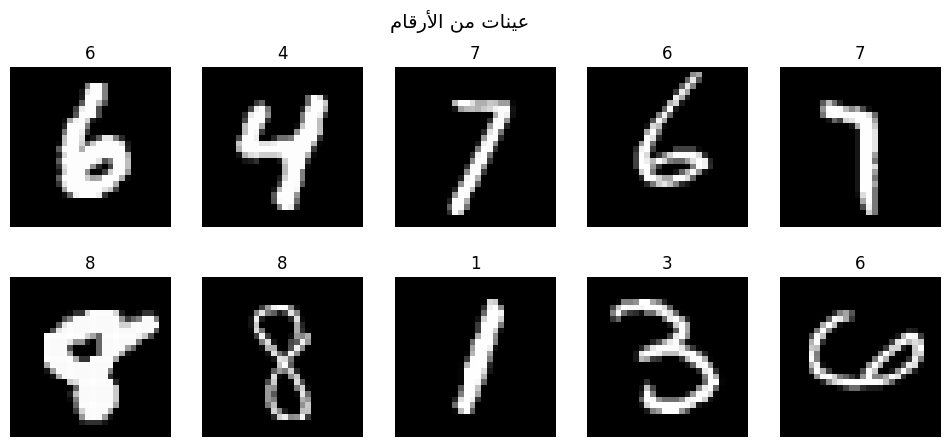

In [9]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle(ar("عينات من الأرقام"), fontsize=14)

for i, axi in enumerate(axes.flat):
    axi.imshow(images[i][0], cmap='gray')
    axi.set_title(f'{labels[i].item()}')
    axi.axis('off')

plt.show()

<div dir="rtl">

### 🏗️ بناء الشبكة العصبية

| الطبقة | الحجم | ماذا تفعل؟ |
|--------|-------|------------|
| **Flatten** | 28×28 ← 784 | **تسطّح** الصورة إلى قائمة أرقام (انتبهوا لهذه الكلمة — سنعود إليها!) |
| **المدخل** | 784 عصبوناً | تستقبل الصورة بكسل بكسل |
| **المخفية 1** | 128 عصبوناً | تكتشف خطوطاً وزوايا بسيطة |
| **المخفية 2** | 64 عصبوناً | تجمع المعلومات لتكوين أشكال |
| **المخرج** | 10 عصبونات | كل عصبون يمثل رقماً (0–9) — الشبكة تختار العصبون الأعلى قيمة وتقول: "هذا هو الرقم!" |

</div>

In [12]:
fc_model = nn.Sequential(
    nn.Flatten(),           # 28×28 → 784  (نسطّح الصورة! 🚩)
    nn.Linear(784, 128),    # طبقة مخفية
    nn.ReLU(),
    nn.Linear(128, 64),     # طبقة مخفية
    nn.ReLU(),
    nn.Linear(64, 10)       # مخرج: 10 أرقام
)

print("🏗️ بنية الشبكة:")
print(fc_model)

fc_params = sum(p.numel() for p in fc_model.parameters())
print(f"\n👥 عدد الأوزان: {fc_params:,}")
print("(قارنوا: شبكة لغز الأذكياء كان فيها 337 وزناً، والبرسبترون 3 فقط!)")

🏗️ بنية الشبكة:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
)

👥 عدد الأوزان: 109,386
(قارنوا: شبكة لغز الأذكياء كان فيها 337 وزناً، والبرسبترون 3 فقط!)


<div dir="rtl">

### لنبدأ بتدريب الشبكة

نستخدم المكوّنات الثلاثة من القسم السابق: خسارة **CrossEntropy** (لأنها مسألة تصنيف)، مُحسّن **Adam**، وحلقة التدريب **بخطواتها الأربع** — ابحثوا عنها في الكود!

</div>

In [13]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(fc_model.parameters(), lr=0.001)

epochs = 5
fc_loss_history = []
fc_accuracy_history = []

print("\nبدء التدريب...\n")

for epoch in range(epochs):
    total_correct = 0
    total_samples = 0
    epoch_loss = 0.0

    progress = tqdm(train_loader, desc=f'دورة {epoch+1}/{epochs}')

    for images, labels in progress:
        optimizer.zero_grad()             # 1) صفّر التدرجات
        outputs = fc_model(images)        # 2) التمرير الأمامي
        loss = loss_fn(outputs, labels)   #    قِس الخسارة
        loss.backward()                   # 3) الانتشار الخلفي — دارتنا تعمل هنا!
        optimizer.step()                  # 4) المُحسّن يعدّل الأوزان

        epoch_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

        progress.set_postfix({
            'الخسارة': f'{loss.item():.3f}',
            'الدقة': f'{total_correct/total_samples:.3f}'
        })

    avg_loss = epoch_loss / len(train_loader)
    accuracy = total_correct / total_samples

    fc_loss_history.append(avg_loss)
    fc_accuracy_history.append(accuracy)

    print(f"الدورة {epoch+1}: دقة {accuracy:.2%}\n")

print("🎉 اكتمل التدريب!")


بدء التدريب...



دورة 1/5:   0%|          | 0/938 [00:00<?, ?it/s]

الدورة 1: دقة 88.07%



دورة 2/5:   0%|          | 0/938 [00:00<?, ?it/s]

الدورة 2: دقة 94.22%



...

الدورة 3: دقة 95.73%



دورة 4/5:   0%|          | 0/938 [00:00<?, ?it/s]

الدورة 4: دقة 96.43%



دورة 5/5:   0%|          | 0/938 [00:00<?, ?it/s]

الدورة 5: دقة 97.01%

🎉 اكتمل التدريب!


<div dir="rtl">

### 📉 منحنى التعلّم

هل الشبكة تتعلم فعلاً؟ الرسم البياني يخبرنا: الخسارة يجب أن **تنخفض** والدقة يجب أن **ترتفع** مع كل حقبة.

</div>

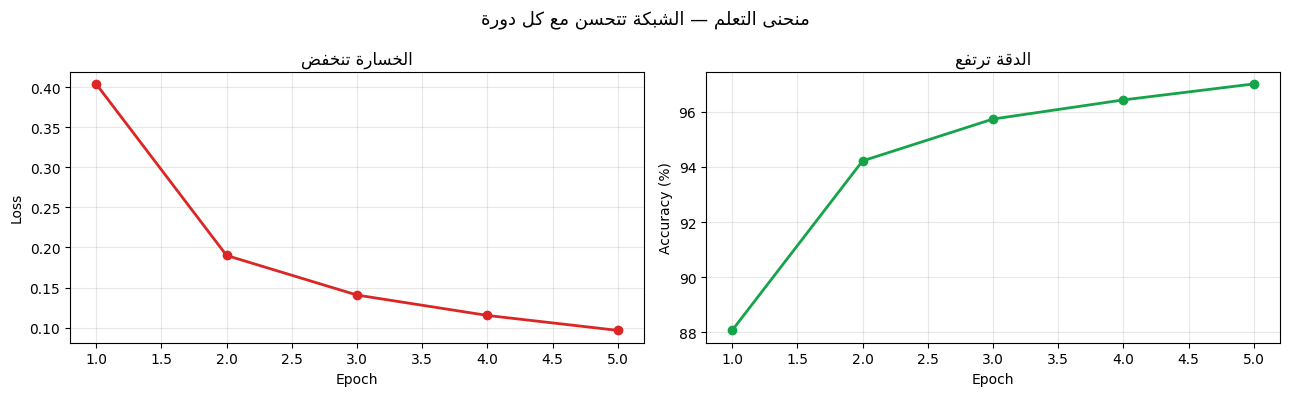

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(range(1, epochs+1), fc_loss_history, 'o-', color='#dc2626', lw=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title(ar('الخسارة تنخفض'))
ax1.grid(alpha=0.3)

ax2.plot(range(1, epochs+1), [a*100 for a in fc_accuracy_history], 'o-', color='#16a34a', lw=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title(ar('الدقة ترتفع'))
ax2.grid(alpha=0.3)

plt.suptitle(ar('منحنى التعلّم — الشبكة تتحسن مع كل دورة'), fontsize=13)
plt.tight_layout()
plt.show()

<div dir="rtl">

### 🧪 لحظة الحقيقة! اختبار الشبكة

الآن نعطي الشبكة **صوراً لم ترها من قبل** لنتأكد أنها تعلّمت فعلاً — ولم "تحفظ" أمثلة التدريب.

</div>

In [15]:
print("\n🧪 اختبار الشبكة...")

fc_model.eval()
correct = 0
total = 0

with torch.no_grad():  # لا نحتاج تدرجات أثناء الاختبار
    for images, labels in tqdm(test_loader, desc='جاري الاختبار'):
        outputs = fc_model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

fc_accuracy = correct / total
print(f"\n🎯 الدقة النهائية: {fc_accuracy:.2%}!")
print(f"✅ أصابت {correct:,} من أصل {total:,} صورة")


🧪 اختبار الشبكة...


جاري الاختبار:   0%|          | 0/157 [00:00<?, ?it/s]


🎯 الدقة النهائية: 96.95%!
✅ أصابت 9,695 من أصل 10,000 صورة


<div dir="rtl">

### توقعات الشبكة

دعونا نرى ماذا تتوقع الشبكة على 10 صور جديدة، ونقارن مع الحقيقة!

</div>

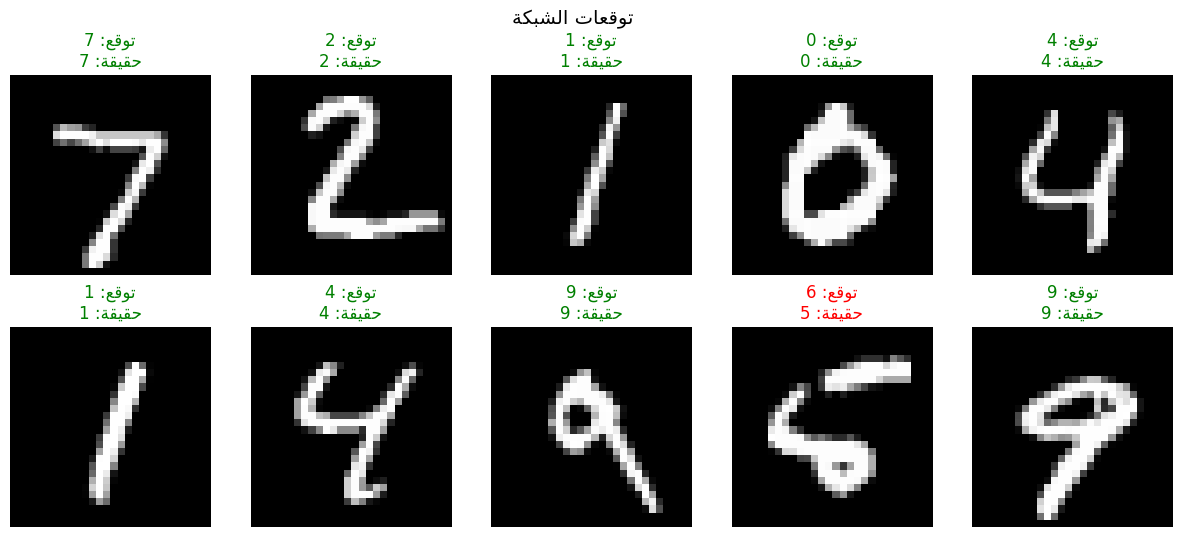

In [16]:
test_images, test_labels = next(iter(test_loader))

with torch.no_grad():
    predictions = fc_model(test_images)
    _, predicted_labels = torch.max(predictions, 1)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(ar("توقعات الشبكة"), fontsize=14)

for i, axi in enumerate(axes.flat):
    axi.imshow(test_images[i][0], cmap='gray')
    pred = predicted_labels[i].item()
    true = test_labels[i].item()
    color = 'green' if pred == true else 'red'
    axi.set_title(ar(f'توقع: {pred}\nحقيقة: {true}'), color=color)
    axi.axis('off')

plt.show()

<div dir="rtl">

### 🔍 أين أخطأت الشبكة؟

أمتع طريقة لفهم شبكة هي النظر إلى **أخطائها**. لاحظوا: كثير من هذه الصور صعبة حتى على البشر — 4 تشبه 9، و 7 تشبه 1...

</div>

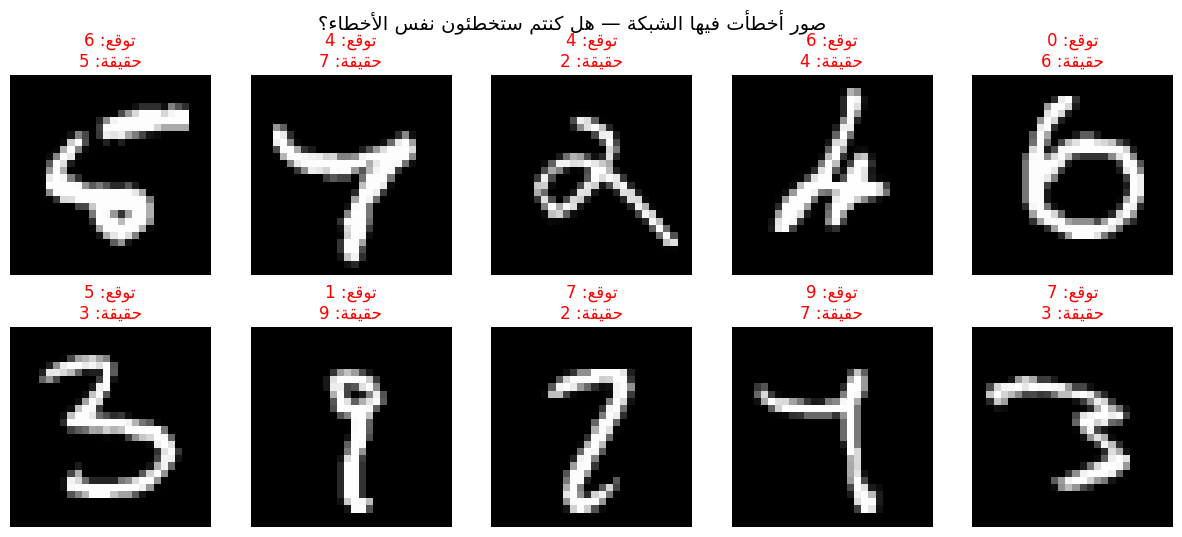

In [17]:
# نجمع أول 10 صور أخطأت فيها الشبكة من مجموعة الاختبار
wrong_images, wrong_preds, wrong_trues = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = fc_model(images)
        _, predicted = torch.max(outputs, 1)
        mistakes = (predicted != labels).nonzero(as_tuple=True)[0]
        for idx in mistakes:
            wrong_images.append(images[idx][0])
            wrong_preds.append(predicted[idx].item())
            wrong_trues.append(labels[idx].item())
        if len(wrong_images) >= 10:
            break

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(ar("صور أخطأت فيها الشبكة — هل كنتم ستخطئون نفس الأخطاء؟"), fontsize=14)

for i, axi in enumerate(axes.flat):
    axi.imshow(wrong_images[i], cmap='gray')
    axi.set_title(ar(f'توقع: {wrong_preds[i]}\nحقيقة: {wrong_trues[i]}'), color='red')
    axi.axis('off')

plt.show()

<div dir="rtl">

---

##  لحظة... هل لاحظتم ماذا فعلنا في أول سطر من الشبكة؟

حققنا دقة رائعة (~97%)، لكن في بنية شبكتنا كان هناك سطر "مريب":

```python
nn.Flatten()   # 28×28 → 784
```

أخذنا صورة — كائناً **ثنائي الأبعاد** له بنية مكانية — و**سطّحناه** إلى قائمة أرقام طويلة. مع MNIST البسيطة نجونا بفعلتنا، لكننا في الحقيقة **دمّرنا معلومات ثمينة**. لنفهم لماذا هذه مشكلة، وكيف نحلها.

</div>

<div dir="rtl">

---

## ⚠️ 4. مشكلة تسطيح الصورة | The Flattening Problem

إن تسطيح الصورة لتصبح مصفوفة أحادية البعد يدمر المعلومات المكانية للبكسلات (Spatial Structure)

### لماذا التسطيح مشكلة؟
- بكسلان متجاوران رأسياً في الصورة يصبحان **بعيدَين** في المصفوفة الأحادية.
- الشبكة العادية **لا تعرف** أنهما كانا جارَين.
- المعلومات المحلية (Local Context) تضيع تماماً!


<div align="center" style="display:flex;justify-content: center;">
<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week5/media/01-flatting-problem.gif">
</div>

**الحل:** نحتاج عملية تحافظ على البنية المكانية — وهنا يأتي **Convolution**.

<div dir="rtl">

---

## ✨ 5. عملية الـ Convolution | The Convolution Operation

> نأخذ **Kernel صغيرة (3×3)** ونُمررها عبر الصورة.

### كيف تعمل؟
1. الـ Kernel يجلس فوق منطقة من الصورة.
2. **نضرب** كل قيمة في الـ kernel بقيمة البكسل المقابل.
3. **نجمع** جميع الحاصلات → رقم واحد في الـ output.
4. ننتقل للموضع التالي ونكرر.

### معادلة حجم الـ Output:
$$\text{Output} = (H - K + 1) \times (W - K + 1)$$

**مثال:**

- صورة **6×6**

- kernel **3×3**

- output **4×4**


In [ ]:
from IPython.display import HTML
from base64 import b64decode
html_content_encoded = "CjxzdHlsZT4KICAgIC5nY2VsbCB7CiAgICAgICAgd2lkdGg6IDQ0cHg7CiAgICAgICAgaGVpZ2h0OiA0NHB4OwogICAgICAgIGJvcmRlci1yYWRpdXM6IDVweDsKICAgICAgICBkaXNwbGF5OiBmbGV4OwogICAgICAgIGFsaWduLWl0ZW1zOiBjZW50ZXI7CiAgICAgICAganVzdGlmeS1jb250ZW50OiBjZW50ZXI7CiAgICAgICAgZm9udC1zaXplOiAuOGVtOwogICAgICAgIGZvbnQtd2VpZ2h0OiBib2xkOwogICAgICAgIHRyYW5zaXRpb246IGFsbCAuM3M7CiAgICAgICAgYm9yZGVyOiAycHggc29saWQgdHJhbnNwYXJlbnQ7CiAgICB9CgogICAgLmljIHsKICAgICAgICBiYWNrZ3JvdW5kOiAjMWUzYTVmOwogICAgICAgIGNvbG9yOiAjOTNjNWZkOwogICAgfQoKICAgIC5pYy5obCB7CiAgICAgICAgYmFja2dyb3VuZDogIzNiODJmNjsKICAgICAgICBib3JkZXItY29sb3I6ICNhNzhiZmE7CiAgICAgICAgY29sb3I6IHdoaXRlOwogICAgICAgIHRyYW5zZm9ybTogc2NhbGUoMS4wNSk7CiAgICB9CgogICAgLmtjIHsKICAgICAgICBiYWNrZ3JvdW5kOiAjNDUxYTAzOwogICAgICAgIGNvbG9yOiAjZmJiZjI0OwogICAgICAgIGJvcmRlcjogMXB4IHNvbGlkICM3ODM1MGY7CiAgICB9CgogICAgLm9jIHsKICAgICAgICBiYWNrZ3JvdW5kOiAjMDY0ZTNiOwogICAgICAgIGNvbG9yOiAjNmVlN2I3OwogICAgICAgIGJvcmRlcjogMXB4IHNvbGlkICMwNjVmNDY7CiAgICB9CgogICAgLm9jLmZpbGxlZCB7CiAgICAgICAgYmFja2dyb3VuZDogIzA1OTY2OTsKICAgICAgICBjb2xvcjogd2hpdGU7CiAgICB9CgogICAgQGtleWZyYW1lcyBwb3AgewogICAgICAgIGZyb20gewogICAgICAgICAgICB0cmFuc2Zvcm06IHNjYWxlKC41KQogICAgICAgIH0KCiAgICAgICAgdG8gewogICAgICAgICAgICB0cmFuc2Zvcm06IHNjYWxlKDEpCiAgICAgICAgfQogICAgfQo8L3N0eWxlPgo8ZGl2IHN0eWxlPSJmb250LWZhbWlseTpTZWdvZSBVSSxzYW5zLXNlcmlmO2JhY2tncm91bmQ6IzBmMTcyYTtwYWRkaW5nOjMwcHg7Ym9yZGVyLXJhZGl1czoxNnB4O2NvbG9yOndoaXRlOyI+CiAgICA8aDMgc3R5bGU9InRleHQtYWxpZ246Y2VudGVyO2NvbG9yOiNhNzhiZmE7bWFyZ2luLWJvdHRvbToyMHB4OyI+4pyoIENvbnZvbHV0aW9uIE9wZXJhdGlvbiDigJQg2KrZgdin2LnZhNmK2Kk8L2gzPgogICAgPGRpdiBzdHlsZT0iZGlzcGxheTpmbGV4O2p1c3RpZnktY29udGVudDpjZW50ZXI7YWxpZ24taXRlbXM6ZmxleC1zdGFydDtnYXA6MjBweDtmbGV4LXdyYXA6d3JhcDsiPgogICAgICAgIDxkaXYgc3R5bGU9InRleHQtYWxpZ246Y2VudGVyOyI+CiAgICAgICAgICAgIDxwIHN0eWxlPSJjb2xvcjojOTRhM2I4O21hcmdpbi1ib3R0b206OHB4OyI+SW5wdXQgKDbDlzYpPC9wPgogICAgICAgICAgICA8ZGl2IGlkPSJpZyIgc3R5bGU9ImRpc3BsYXk6Z3JpZDtncmlkLXRlbXBsYXRlLWNvbHVtbnM6cmVwZWF0KDYsNDRweCk7Z2FwOjJweDsiPjwvZGl2PgogICAgICAgIDwvZGl2PgogICAgICAgIDxkaXYgc3R5bGU9InRleHQtYWxpZ246Y2VudGVyOyI+CiAgICAgICAgICAgIDxwIHN0eWxlPSJjb2xvcjojZmJiZjI0O21hcmdpbi1ib3R0b206OHB4OyI+S2VybmVsICgzw5czKTwvcD4KICAgICAgICAgICAgPGRpdiBpZD0ia2ciIHN0eWxlPSJkaXNwbGF5OmdyaWQ7Z3JpZC10ZW1wbGF0ZS1jb2x1bW5zOnJlcGVhdCgzLDQ0cHgpO2dhcDoycHg7Ij48L2Rpdj4KICAgICAgICAgICAgPGRpdiBpZD0iY2QiCiAgICAgICAgICAgICAgICBzdHlsZT0ibWFyZ2luLXRvcDoxMHB4O3BhZGRpbmc6MTBweDtiYWNrZ3JvdW5kOiMxZTI5M2I7Ym9yZGVyLXJhZGl1czo4cHg7Zm9udC1zaXplOi44ZW07Y29sb3I6I2E3OGJmYTttaW4taGVpZ2h0OjUwcHg7bWluLXdpZHRoOjE1MHB4OyI+CiAgICAgICAgICAgIDwvZGl2PgogICAgICAgIDwvZGl2PgogICAgICAgIDxkaXYgc3R5bGU9InRleHQtYWxpZ246Y2VudGVyOyI+CiAgICAgICAgICAgIDxwIHN0eWxlPSJjb2xvcjojMzRkMzk5O21hcmdpbi1ib3R0b206OHB4OyI+T3V0cHV0ICg0w5c0KTwvcD4KICAgICAgICAgICAgPGRpdiBpZD0ib2ciIHN0eWxlPSJkaXNwbGF5OmdyaWQ7Z3JpZC10ZW1wbGF0ZS1jb2x1bW5zOnJlcGVhdCg0LDQ0cHgpO2dhcDoycHg7Ij48L2Rpdj4KICAgICAgICA8L2Rpdj4KICAgIDwvZGl2PgogICAgPGRpdiBzdHlsZT0idGV4dC1hbGlnbjpjZW50ZXI7bWFyZ2luLXRvcDoyMHB4O2Rpc3BsYXk6ZmxleDtnYXA6MTBweDtqdXN0aWZ5LWNvbnRlbnQ6Y2VudGVyO2ZsZXgtd3JhcDp3cmFwOyI+CiAgICAgICAgPGJ1dHRvbiBvbmNsaWNrPSJzdGVwQygpIgogICAgICAgICAgICBzdHlsZT0iYmFja2dyb3VuZDojNmQyOGQ5O2NvbG9yOndoaXRlO2JvcmRlcjpub25lO3BhZGRpbmc6MTBweCAyMnB4O2JvcmRlci1yYWRpdXM6OHB4O2N1cnNvcjpwb2ludGVyO2ZvbnQtc2l6ZToxZW07Ij7ilrYKICAgICAgICAgICAg2K7Yt9mI2KkgfCBTdGVwPC9idXR0b24+CiAgICAgICAgPGJ1dHRvbiBvbmNsaWNrPSJhdXRvQygpIgogICAgICAgICAgICBzdHlsZT0iYmFja2dyb3VuZDojMDU5NjY5O2NvbG9yOndoaXRlO2JvcmRlcjpub25lO3BhZGRpbmc6MTBweCAyMnB4O2JvcmRlci1yYWRpdXM6OHB4O2N1cnNvcjpwb2ludGVyO2ZvbnQtc2l6ZToxZW07Ij7ij6kKICAgICAgICAgICAg2KrZhNmC2KfYptmKIHwgQXV0bzwvYnV0dG9uPgogICAgICAgIDxidXR0b24gb25jbGljaz0icmVzZXRDKCkiCiAgICAgICAgICAgIHN0eWxlPSJiYWNrZ3JvdW5kOiMzNzQxNTE7Y29sb3I6d2hpdGU7Ym9yZGVyOm5vbmU7cGFkZGluZzoxMHB4IDIycHg7Ym9yZGVyLXJhZGl1czo4cHg7Y3Vyc29yOnBvaW50ZXI7Zm9udC1zaXplOjFlbTsiPuKGugogICAgICAgICAgICDYpdi52KfYr9ipPC9idXR0b24+CiAgICA8L2Rpdj4KPC9kaXY+CjxzY3JpcHQ+CiAgICBjb25zdCBpbnAgPSBbWzEsIDIsIDMsIDAsIDEsIDJdLCBbNCwgNSwgNiwgMSwgMCwgM10sIFs3LCA4LCA5LCAyLCAxLCA0XSwgWzAsIDEsIDIsIDMsIDQsIDVdLCBbMSwgMiwgMywgNCwgNSwgNl0sIFsyLCAzLCA0LCA1LCA2LCA3XV07CiAgICBjb25zdCBrZXIgPSBbWzEsIDAsIC0xXSwgWzEsIDAsIC0xXSwgWzEsIDAsIC0xXV07CiAgICBsZXQgc3QgPSAwLCBhdCA9IG51bGw7CiAgICBmdW5jdGlvbiBidWlsZCgpIHsKICAgICAgICBjb25zdCBpZyA9IGRvY3VtZW50LmdldEVsZW1lbnRCeUlkKCJpZyIpLCBrZyA9IGRvY3VtZW50LmdldEVsZW1lbnRCeUlkKCJrZyIpLCBvZyA9IGRvY3VtZW50LmdldEVsZW1lbnRCeUlkKCJvZyIpOwogICAgICAgIGlnLmlubmVySFRNTCA9IGtnLmlubmVySFRNTCA9IG9nLmlubmVySFRNTCA9ICIiOwogICAgICAgIGlucC5mb3JFYWNoKChyb3csIHIpID0+IHJvdy5mb3JFYWNoKCh2LCBjKSA9PiB7IGNvbnN0IGQgPSBkb2N1bWVudC5jcmVhdGVFbGVtZW50KCJkaXYiKTsgZC5jbGFzc05hbWUgPSAiZ2NlbGwgaWMiOyBkLmlkID0gYGktJHtyfS0ke2N9YDsgZC50ZXh0Q29udGVudCA9IHY7IGlnLmFwcGVuZENoaWxkKGQpOyB9KSk7CiAgICAgICAga2VyLmZvckVhY2goKHJvdywgcikgPT4gcm93LmZvckVhY2goKHYsIGMpID0+IHsgY29uc3QgZCA9IGRvY3VtZW50LmNyZWF0ZUVsZW1lbnQoImRpdiIpOyBkLmNsYXNzTmFtZSA9ICJnY2VsbCBrYyI7IGQudGV4dENvbnRlbnQgPSB2OyBrZy5hcHBlbmRDaGlsZChkKTsgfSkpOwogICAgICAgIGZvciAobGV0IGkgPSAwOyBpIDwgMTY7IGkrKykgeyBjb25zdCBkID0gZG9jdW1lbnQuY3JlYXRlRWxlbWVudCgiZGl2Iik7IGQuY2xhc3NOYW1lID0gImdjZWxsIG9jIjsgZC5pZCA9IGBvLSR7TWF0aC5mbG9vcihpIC8gNCl9LSR7aSAlIDR9YDsgZC50ZXh0Q29udGVudCA9ICI/Ijsgb2cuYXBwZW5kQ2hpbGQoZCk7IH0KICAgIH0KICAgIGZ1bmN0aW9uIHN0ZXBDKCkgewogICAgICAgIGlmIChzdCA+PSAxNikgcmV0dXJuOwogICAgICAgIGNvbnN0IHIgPSBNYXRoLmZsb29yKHN0IC8gNCksIGMgPSBzdCAlIDQ7CiAgICAgICAgZG9jdW1lbnQucXVlcnlTZWxlY3RvckFsbCgiLmljIikuZm9yRWFjaChlID0+IGUuY2xhc3NMaXN0LnJlbW92ZSgiaGwiKSk7CiAgICAgICAgbGV0IHN1bSA9IDAsIHRlcm1zID0gW107CiAgICAgICAgZm9yIChsZXQga3IgPSAwOyBrciA8IDM7IGtyKyspZm9yIChsZXQga2MgPSAwOyBrYyA8IDM7IGtjKyspIHsKICAgICAgICAgICAgZG9jdW1lbnQuZ2V0RWxlbWVudEJ5SWQoYGktJHtyICsga3J9LSR7YyArIGtjfWApLmNsYXNzTGlzdC5hZGQoImhsIik7CiAgICAgICAgICAgIGNvbnN0IHAgPSBpbnBbciArIGtyXVtjICsga2NdICoga2VyW2tyXVtrY107IHN1bSArPSBwOwogICAgICAgICAgICBpZiAocCAhPT0gMCkgdGVybXMucHVzaChgJHtpbnBbciArIGtyXVtjICsga2NdfXgke2tlcltrcl1ba2NdfWApOwogICAgICAgIH0KICAgICAgICBkb2N1bWVudC5nZXRFbGVtZW50QnlJZCgiY2QiKS5pbm5lckhUTUwgPSBgPHNwYW4gc3R5bGU9ImNvbG9yOiNmYmJmMjQ7Ij7Yp9mE2K3Ys9in2Kg6PC9zcGFuPjxicj4ke3Rlcm1zLnNsaWNlKDAsIDQpLmpvaW4oIiArICIpfS4uLjxicj48c3BhbiBzdHlsZT0iY29sb3I6IzM0ZDM5OTsiPj0gJHtzdW19PC9zcGFuPmA7CiAgICAgICAgY29uc3Qgb2MgPSBkb2N1bWVudC5nZXRFbGVtZW50QnlJZChgby0ke3J9LSR7Y31gKTsgb2MudGV4dENvbnRlbnQgPSBzdW07IG9jLmNsYXNzTGlzdC5hZGQoImZpbGxlZCIpOyBvYy5zdHlsZS5hbmltYXRpb24gPSAicG9wIC4zcyBlYXNlIjsKICAgICAgICBzdCsrOwogICAgfQogICAgZnVuY3Rpb24gYXV0b0MoKSB7IGlmIChhdCkgeyBjbGVhckludGVydmFsKGF0KTsgYXQgPSBudWxsOyByZXR1cm47IH0gYXQgPSBzZXRJbnRlcnZhbCgoKSA9PiB7IGlmIChzdCA+PSAxNikgeyBjbGVhckludGVydmFsKGF0KTsgYXQgPSBudWxsOyByZXR1cm47IH0gc3RlcEMoKTsgfSwgNjAwKTsgfQogICAgZnVuY3Rpb24gcmVzZXRDKCkgeyBpZiAoYXQpIHsgY2xlYXJJbnRlcnZhbChhdCk7IGF0ID0gbnVsbDsgfSBzdCA9IDA7IGJ1aWxkKCk7IGRvY3VtZW50LmdldEVsZW1lbnRCeUlkKCJjZCIpLmlubmVySFRNTCA9ICIiOyB9CiAgICBidWlsZCgpOwo8L3NjcmlwdD4="
HTML(b64decode(html_content_encoded).decode("utf-8"))

<div dir="rtl">

---

## 6. الـ Kernels المتعددة وعمق الصورة

### أولاً: لماذا نستخدم Kernels متعددة؟

كل **Kernel** مسؤولة عن اكتشاف **نمط واحد فقط** من الصورة.  
مثلاً: Kernel تكتشف الحواف الرأسية، وأخرى تكتشف الحواف الأفقية، وثالثة تكتشف الزوايا...

لذلك، نستخدم **عدة Kernels في نفس الوقت** على نفس الصورة، كل واحدة تُنتج خريطة ميزات (Feature Map) مستقلة.

$$\text{عدد الـ Output Channels} = \text{عدد الـ Kernels}$$




<div dir="rtl">

---

### ثانياً: فهم الأبعاد — ماذا تعني الرموز؟

لنبدأ بتعريف كل رمز بوضوح:

| الرمز | الاسم | المعنى |
|:-----:|:------|:-------|
| $H$ | Height — الارتفاع | عدد الصفوف (الأسطر) في الصورة أو الـ Feature Map |
| $W$ | Width — العرض | عدد الأعمدة في الصورة أو الـ Feature Map |
| $C$ | Channels (المدخل) | عمق الصورة المدخلة — كم طبقة فيها؟ |
| $K$ | Kernel Size — حجم الـ Kernel | طول وعرض نافذة الـ Kernel (مثلاً $3 \times 3$) |
| $C'$ | Channels (المخرج) | عدد الـ Feature Maps الناتجة = عدد الـ Kernels التي استخدمناها |
| $H'$ | Height الناتج | ارتفاع الـ Feature Map بعد تطبيق الـ Convolution |
| $W'$ | Width الناتج | عرض الـ Feature Map بعد تطبيق الـ Convolution |



<div dir="rtl">

---

### ثالثاً: حساب أبعاد الـ Feature Map

عندما نُمرِّر Kernel حجمها $K \times K$ على صورة حجمها $H \times W$، تصبح أبعاد الخرج الناتجة:

$$H' = H - K + 1$$

$$W' = W - K + 1$$

**مثال عددي:**
- صورة حجمها $6 \times 6$ أي $H=6,\ W=6$
- Kernel حجمها $3 \times 3$ أي $K=3$
- إذن: $H' = 6 - 3 + 1 = 4$ و $W' = 6 - 3 + 1 = 4$
- الخرج سيكون بحجم $4 \times 4$ ✅



<div dir="rtl">

---

### رابعاً: الصور الملونة — RGB Images

الصورة الرمادية (Grayscale) لها طبقة واحدة فقط، لكن الصورة الملونة لها **ثلاث طبقات**:

$$\underbrace{H \times W}_{\text{الأبعاد المكانية}} \times \underbrace{C}_{\text{عمق القناة}}$$

بالنسبة لصورة RGB:
$$C = 3 \quad \text{(Red, Green, Blue)}$$

حتى تتمكن الـ Kernel من معالجة الصورة الملونة، يجب أن يكون لها نفس عمق الصورة:

$$\text{حجم الـ Kernel} = K \times K \times C$$

في كل موضع، تضرب الـ Kernel كل قيمة في الـ $K \times K \times C$ عناصر وتجمعها → **رقم واحد فقط** كناتج.



<div dir="rtl">

---

### خامساً: الصورة الكاملة — من المدخل إلى المخرج

إذا استخدمنا $C'$ من الـ Kernels على صورة ملونة:

$$\underbrace{H \times W \times C}_{\text{المدخل}} \xrightarrow{\text{\ } C' \text{ Kernels\ }} \underbrace{H' \times W' \times C'}_{\text{المخرج}}$$

**تلخيص المعادلات الأساسية:**

$$H' = H - K + 1$$

$$W' = W - K + 1$$

$$C' = \text{عدد الـ Kernels}$$

---

### مثال شامل:

- **مدخل:** صورة ملونة $224 \times 224 \times 3$
- **نستخدم:** $32$ Kernel حجم كل منها $3 \times 3 \times 3$
- **الناتج:**

$$H' = 224 - 3 + 1 = 222$$
$$W' = 224 - 3 + 1 = 222$$
$$C' = 32$$

$$\text{الـ Output Volume} = 222 \times 222 \times 32$$

> 💡 **الفكرة الجوهرية:** كل Kernel تُنتج Feature Map مستقلة تكتشف نمطاً مختلفاً.  
> كلما زاد عدد الـ Kernels ($C'$)، زادت الأنماط التي تتعلمها الشبكة من الصورة.

</div>

<div dir="rtl">

---

## 🔗 7. تراكم طبقات CNN | Stacking CNN Layers

في شبكة CNN حقيقية، لا نكتفي بتطبيق Convolution مرة واحدة — بل نُكرِّر العملية عبر طبقات متعددة، حيث **ناتج كل طبقة يصبح مدخل الطبقة التالية** تلقائياً. هذا التراكم هو ما يمنح الشبكة قدرتها على فهم الصور بعمق.

---
في الشكل التالي مثال حول المسار الكامل للشبكة العصبية CNN

<div align="center" style="display:flex;justify-content: center;">
<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week5/media/04-full-cnn-pipeline.png">
</div>

### ماذا يحدث لأبعاد البيانات مع كل طبقة؟

| الطبقة | الأبعاد المكانية ($H \times W$) | عدد الـ Channels ($C$) | ما الذي يحدث؟ |
|:-------|:-------------------------------|:----------------------|:--------------|
| **Input** | كبيرة — $224 \times 224$ | $3$ (RGB) | الصورة الأصلية الخام |
| **Conv 1** | تصغر — $112 \times 112$ | تزيد — $32$ | تكتشف حواف وتدرجات بسيطة |
| **Conv 2** | تصغر — $56 \times 56$ | تزيد — $64$ | تُركِّب الحواف في أشكال وزوايا |
| **Conv 3** | صغيرة جداً — $28 \times 28$ أو أقل | كثيرة جداً — $256$ أو $512$ | تتعرف على أجزاء وأنماط معقدة |
| **Flatten** | يتحول إلى مصفوفة أحادية البعد 1D | — | تحويل الـ Volume إلى قائمة أرقام |
| **FC + Softmax** | — | — | التصنيف النهائي |

---

### لماذا تصغر الأبعاد المكانية؟

في كل طبقة، تعمل عمليتان معاً على تقليص $H$ و $W$:

1. **الـ Convolution نفسها:** كما رأينا في المعادلة $H' = H - K + 1$، كل تطبيق للـ Kernel يُقلِّل الأبعاد قليلاً.
2. **الـ Max Pooling:** بعد كل طبقة Convolution عادةً، نُطبِّق Pooling يُقلِّص الأبعاد إلى النصف مرة واحدة — مثلاً $224 > 112 > 56 > 28$.

---

### لماذا يزيد عدد الـ Channels في نفس الوقت؟

عندما تصغر الأبعاد المكانية، نُعوِّض ذلك بزيادة عدد الـ Kernels في كل طبقة. أي أن:

$$\text{الطبقات الأولى: } H,W \text{ كبيرة} \quad C \text{ صغير}$$

$$\text{الطبقات العميقة: } H,W \text{ صغيرة} \quad C \text{ كبير}$$

هذا التبادل مقصود — الشبكة **تتنازل عن الدقة المكانية مقابل ثراء التمثيل (Feature Richness)**. بمعنى آخر: بدلاً من أن تعرف "أين بالضبط" كل بكسل، تصبح تعرف "ماذا يوجد" في الصورة بشكل أعمق.
<div align="center" style="display:flex;justify-content: center;">
<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week5/media/05-cnn-depth-size.gif?a=a">
</div>



---

### ماذا يعني الـ Flatten؟

في نهاية طبقات الـ Convolution، لدينا حجم ثلاثي الأبعاد (Volume) بأبعاد صغيرة مثل $7 \times 7 \times 512$.  
نُحوِّله إلى متجه أحادي الأبعاد بطول:

$$7 \times 7 \times 512 = 25{,}088 \text{ رقم}$$

هذا المتجه هو **Feature Vector** — وهو ملخص الشبكة للصورة بأكملها. لا يحتوي على مواضع البكسلات، بل على **تقطير -خلاصة- لأهم الأنماط والميزات** التي تعلمتها الشبكة عبر كل طبقاتها، مضغوطةً في شكل مناسب لاتخاذ قرار التصنيف النهائي عبر الـ Fully Connected Layer.

</div>

<div dir="rtl">

---

## 🏊 8. الـ Max Pooling

**Max Pooling** هي عملية تقليص مقصودة تُقلِّص الأبعاد المكانية ($H$ و $W$) للـ Feature Map مع الاحتفاظ بأهم المعلومات فيها. تأتي عادةً بعد كل طبقة Convolution مباشرةً، وتُشكِّل معها ثنائياً أساسياً في بنية الـ CNN.

### كيف يعمل؟

1. نأخذ **نافذة $2 \times 2$** ونُمرِّرها على الـ Feature Map **بدون تداخل** (أي أن النافذة تقفز بمقدار 2 في كل خطوة — وهذا ما يُسمى الـ Stride).
2. من كل نافذة نأخذ **القيمة العظمى (Maximum)** فقط ونتجاهل الثلاث قيم الأخرى.
3. خريطة $4 \times 4$ تصبح $2 \times 2$ — أي تقليل الأبعاد بنسبة $75\%$ دفعةً واحدة!

بشكل عام، أي Feature Map بأبعاد $H \times W$ تصبح بعد تطبيق Max Pooling حجمه $2 \times 2$ كالتالي:

$$H' = \frac{H}{2} \qquad W' = \frac{W}{2}$$
<div align="center" style="display:flex;justify-content: center;">
<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week5/media/06-maxpooling.gif">
</div>

### لماذا نأخذ الـ Maximum تحديداً؟

القيمة العظمى في النافذة تمثل **أقوى استجابة** للـ Kernel في تلك المنطقة — أي أنها تُجيب على سؤال: **"هل وُجد هذا النمط في هذه المنطقة؟"**. لا يهمنا أين بالضبط داخل النافذة، يكفي أنه موجود. بهذا نحتفظ بـ **وجود الميزة** ونتخلى عن **موضعها الدقيق**، وهذا بالضبط ما يمنح الشبكة خاصية الـ Translation Invariance التي سنشرحها لاحقا — أي أن الكائن يُتعرَّف عليه بصرف النظر عن مكانه في الصورة.

بخلاف Max Pooling، هناك نوع آخر يُسمى **Average Pooling** يأخذ متوسط القيم بدل الأعلى، لكن Max Pooling أثبت تفوقاً عملياً في معظم مهام رؤية الحاسوب لأن الميزات القوية في الصورة تُشفَّر في القيم العالية لا في المتوسطات.

</div>

<div dir="rtl">

---

## 🧬 9. لماذا تتفوق CNN على الشبكات العادية؟

تخيّل أنك تُريد تعليم طفل التعرف على القطط — لن تُريه كل بكسل في الصورة وتقول "احفظ هذا". بدلاً من ذلك ستُعلِّمه: "انظر للأذنين المدببتين، والعينين اللوزيتين، والفراء". هذا بالضبط ما تفعله الـ CNN — لكن بدلاً من أن نُخبرها بما تبحث عنه، **تتعلمه بنفسها من البيانات**.

الـ CNN لا تتفوق بالصدفة. بنيتها مصممة بناءً على **افتراضات ذكية مدمجة في معمارها** تعكس حقائق فيزيائية حقيقية عن طبيعة الصور. هذه الافتراضات تُسمى **Inductive Biases**، وهي التي تجعلها أكثر كفاءةً بما لا يُقاس من الشبكات العصبية العادية (Fully Connected Networks) عند التعامل مع البيانات البصرية — سواء كانت صوراً أو فيديوهات أو حتى أشعة طبية.


</div>


<div dir="rtl">


---

### 9.1. 🎯 Local Connectivity — الاتصال المحلي

كل نيورون في طبقة الـ Convolution **لا يرى سوى منطقة صغيرة محلية** من الصورة — فقط الـ $K \times K$ بكسل التي تغطيها الـ Kernel، ولا يعلم شيئاً عمّا يقع خارجها.

**لماذا هذا منطقي؟** لأن في الصور الحقيقية، البكسلات القريبة من بعضها هي التي تحمل معلومات مشتركة — حافة السيارة، ريشة الطائر، حرف في كلمة. أما بكسل في الركن الأيسر العلوي فلا علاقة له عموماً ببكسل في الركن الأيمن السفلي.

**مثال:** لو أردنا اكتشاف عيون الإنسان في صورة، لا نحتاج للنظر إلى القدمين — يكفي النظر إلى منطقة الوجه. الاتصال المحلي يجعل الشبكة تفعل ذلك تلقائياً.

**القوة:** في شبكة Fully Connected على صورة $224 \times 224 \times 3$، كل نيورون يرى $224 \times 224 \times 3 = 150{,}528$ قيمة. في CNN، كل نيورون يرى $3 \times 3 \times 3 = 27$ قيمة فقط — تقليل بمقدار $\times 5{,}575$ في عدد العمليات الحسابية لكل نيورون.

</div>
<div align="center" style="display:flex;justify-content: center;">
<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week5/media/08-1local-connectivity.gif">
</div>



<div dir="rtl">
---


### 9.2. ↔️ Translation Equivariance — التحول المتساوي

إذا تحركت ميزة ما في الصورة المدخلة، **يتحرك الناتج في الـ Feature Map بنفس المقدار** تماماً. الـ Convolution لا تُفضِّل موضعاً على آخر — تُطبَّق بنفس الطريقة في كل مكان.

**مثال:** إذا كانت حافة رأسية تقع عند العمود الثالث في الصورة، فستظهر الاستجابة عند العمود الثالث في الـ Feature Map. لو تحركت الحافة إلى العمود السادس، تتبعها الاستجابة تلقائياً دون أي تدريب إضافي.

**القوة:** الشبكة تتعلم اكتشاف الحافة **مرة واحدة فقط**، وتُطبِّق هذا التعلم في كل موضع من الصورة — في أعلى اليمين، أسفل اليسار، في المنتصف، في كل مكان.

</div>
<div align="center" style="display:flex;justify-content: center;">
<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week5/media/08-2-translation-eq.png">
</div>


<div dir="rtl">
---


### 9.3. ♻️ Parameter Sharing — مشاركة البارمترات


**نفس الـ Kernel بنفس الأوزان** تُمرَّر على كل مواضع الصورة. لا توجد Kernel مختلفة للركن الأيسر وأخرى للركن الأيمن — Kernel واحدة تفعل كل شيء.

**مثال:** Kernel مدرَّبة على اكتشاف الحواف الرأسية ستكتشفها سواء كانت الحافة في السماء أو على الأرض أو في المنتصف — نفس الأوزان، نفس القدرة، في كل موضع.

**القوة:** لو كان لدينا Kernel مستقلة لكل موضع في صورة $224 \times 224$، لاحتجنا إلى:
$$224 \times 224 \times (3 \times 3 \times 3) = 1{,}354{,}752 \text{ معامل لـ Kernel واحدة فقط!}$$
لكن بفضل Parameter Sharing، كل Kernel تحتاج فقط:
$$3 \times 3 \times 3 = 27 \text{ معامل}$$
هذا تقليل بمقدار $\times 50{,}000$ في عدد المعاملات — مما يجعل التدريب أسرع وأقل عرضة للـ Overfitting.

</div>
<div align="center" style="display:flex;justify-content: center;">
<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week5/media/08-3parameter-sharing.gif">
</div>




<div dir="rtl">
---


### 9.4. 🐱 Translation Invariance — ثبات الترجمة

بفضل الـ Max Pooling، لا يهم أين يقع الكائن في الصورة — **الشبكة ستُصنِّفه بنفس الدقة** سواء كان في الركن أو المنتصف أو أي مكان آخر.

**مثال:** صورة قطة في الجهة اليسرى وصورة نفس القطة في الجهة اليمنى — كلتاهما تحصل على نفس التصنيف "قطة". هذا لأن الـ Pooling تُدمِّر المعلومات الموضعية الدقيقة تدريجياً طبقةً بعد طبقة، محتفظةً فقط بـ "هل الميزة موجودة؟" لا "أين هي بالضبط؟"

**القوة:** بدون هذه الخاصية، كانت الشبكة ستحتاج لرؤية القطة في **كل موضع ممكن** من الصورة أثناء التدريب حتى تتعلم التعميم — وهذا يعني بيانات تدريب أكبر بأضعاف مضاعفة.

</div>

<div align="center" style="display:flex;justify-content: center;">
<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week5/media/08-4translation-inv.png">
</div>



<div dir="rtl">
---


### 9.5. 🏔️ Hierarchical Features — التسلسل الهرمي للميزات

الطبقات لا تتعلم كلها على نفس المستوى من التجريد — بل تبني فهمها **من البسيط إلى المعقد** تدريجياً:

$$\underbrace{\text{حواف وتدرجات}}_{\text{Layer 1}} \longrightarrow \underbrace{\text{أشكال وأنسجة}}_{\text{Layer 2}} \longrightarrow \underbrace{\text{أجزاء: عين، عجلة، ورقة}}_{\text{Layer 3}} \longrightarrow \underbrace{\text{كائنات كاملة: وجه، سيارة، شجرة}}_{\text{Layer 4+}}$$

**مثال:** لتعرُّف الشبكة على وجه إنسان — الطبقة الأولى تكتشف الحواف، الثانية تُركِّبها في أشكال بيضاوية، الثالثة تعرف أن هذه الأشكال قد تكون عيناً أو فماً، والطبقة الأعمق تُركِّب كل ذلك معاً لتقول: "هذا وجه إنسان".

**القوة:** هذا التسلسل يعني أن الطبقات الأولى **قابلة لإعادة الاستخدام** عبر مهام مختلفة — الحواف والأشكال البسيطة مفيدة سواء كنا نُصنِّف قطط أو سيارات أو أشعة طبية. هذا هو أساس فكرة الـ **Transfer Learning** التي سنتعلمها لاحقاً.


</div>

In [ ]:
from IPython.display import HTML
from base64 import b64decode
html_encoded = "PHN0eWxlPgogICAgLmhpIHsKICAgICAgICBkaXNwbGF5OiBmbGV4OwogICAgICAgIGFsaWduLWl0ZW1zOiBmbGV4LXN0YXJ0OwogICAgICAgIGdhcDogMjBweDsKICAgICAgICBwYWRkaW5nLWxlZnQ6IDM1cHg7CiAgICAgICAgbWFyZ2luLWJvdHRvbTogMThweDsKICAgIH0KCiAgICAuaGQgewogICAgICAgIHdpZHRoOiAyMnB4OwogICAgICAgIGhlaWdodDogMjJweDsKICAgICAgICBib3JkZXItcmFkaXVzOiA1MCU7CiAgICAgICAgYm9yZGVyOiAzcHggc29saWQ7CiAgICAgICAgZmxleC1zaHJpbms6IDA7CiAgICAgICAgbWFyZ2luLXRvcDogMTBweDsKICAgICAgICBib3gtc2hhZG93OiAwIDAgMTBweCByZ2JhKDI1NSwgMjU1LCAyNTUsIC4zKTsKICAgIH0KCiAgICAuaGIgewogICAgICAgIGZsZXg6IDE7CiAgICAgICAgcGFkZGluZzogMTRweCAxOHB4OwogICAgICAgIGJvcmRlci1yYWRpdXM6IDEwcHg7CiAgICAgICAgYm9yZGVyOiAxcHggc29saWQ7CiAgICAgICAgdHJhbnNpdGlvbjogdHJhbnNmb3JtIC4yczsKICAgIH0KCiAgICAuaGI6aG92ZXIgewogICAgICAgIHRyYW5zZm9ybTogdHJhbnNsYXRlWCg1cHgpOwogICAgfQoKICAgIEBrZXlmcmFtZXMgc1IgewogICAgICAgIGZyb20gewogICAgICAgICAgICBvcGFjaXR5OiAwOwogICAgICAgICAgICB0cmFuc2Zvcm06IHRyYW5zbGF0ZVgoLTMwMHB4KQogICAgICAgIH0KCiAgICAgICAgdG8gewogICAgICAgICAgICBvcGFjaXR5OiAxOwogICAgICAgICAgICB0cmFuc2Zvcm06IHRyYW5zbGF0ZVgoMCkKICAgICAgICB9CiAgICB9Cjwvc3R5bGU+CjxkaXYgZGlyPSJydGwiIHN0eWxlPSJmb250LWZhbWlseTpTZWdvZSBVSSxzYW5zLXNlcmlmO2JhY2tncm91bmQ6IzBmMTcyYTtwYWRkaW5nOjMwcHg7Ym9yZGVyLXJhZGl1czoxNnB4O2NvbG9yOndoaXRlOyI+CiAgICA8aDMgc3R5bGU9InRleHQtYWxpZ246Y2VudGVyO2NvbG9yOiNhNzhiZmE7bWFyZ2luLWJvdHRvbToyNXB4OyI+8J+PlO+4jyDYp9mE2KrYs9mE2LPZhCDYp9mE2YfYsdmF2Yog2YTZhNmF2YrYstin2Ko8L2gzPgogICAgPGRpdiBzdHlsZT0icG9zaXRpb246cmVsYXRpdmU7bWF4LXdpZHRoOjY4MHB4O21hcmdpbjowIGF1dG87Ij4KICAgICAgICA8ZGl2CiAgICAgICAgICAgIHN0eWxlPSJwb3NpdGlvbjphYnNvbHV0ZTtyaWdodDoxM3B4O3RvcDowO2JvdHRvbTowO3dpZHRoOjNweDtiYWNrZ3JvdW5kOmxpbmVhci1ncmFkaWVudCgxODBkZWcsIzNiODJmNiwjNmQyOGQ5LCNhNzhiZmEsI2VjNDg5OSk7Ym9yZGVyLXJhZGl1czozcHg7Ij4KICAgICAgICA8L2Rpdj4KCiAgICAgICAgPGRpdiBjbGFzcz0iaGkiIHN0eWxlPSJhbmltYXRpb246c1IgLjVzIGVhc2UgLjFzIGJvdGg7Ij4KICAgICAgICAgICAgPGRpdiBjbGFzcz0iaGQiIHN0eWxlPSJiYWNrZ3JvdW5kOiMzYjgyZjY7Ym9yZGVyLWNvbG9yOiM5M2M1ZmQ7Ij48L2Rpdj4KICAgICAgICAgICAgPGRpdiBjbGFzcz0iaGIiIHN0eWxlPSJib3JkZXItY29sb3I6IzNiODJmNjtiYWNrZ3JvdW5kOnJnYmEoNTksMTMwLDI0NiwuMSk7Ij4KICAgICAgICAgICAgICAgIDxwIHN0eWxlPSJjb2xvcjojOTNjNWZkO2ZvbnQtd2VpZ2h0OmJvbGQ7bWFyZ2luOjA7Ij7Yp9mE2YXYs9iq2YjZiSDYp9mE2KPZiNmEIC0g2YXZitiy2KfYqiDYqNiz2YrYt9ipPC9wPgogICAgICAgICAgICAgICAgPHAgc3R5bGU9ImNvbG9yOiNjYmQ1ZTE7Zm9udC1zaXplOi45ZW07bWFyZ2luOjhweCAwIDA7Ij7YrdmI2KfZgSDYqNiz2YrYt9ip2Iwg2KrYr9ix2KzYp9iq2Iwg2K7Yt9mI2Lcg2LHYo9iz2YrYqSDZiNij2YHZgtmK2Kk8L3A+CiAgICAgICAgICAgICAgICA8cCBzdHlsZT0iY29sb3I6IzQ3NTU2OTtmb250LXNpemU6LjhlbTttYXJnaW46M3B4IDAgMDsiPtit2YjYp9mBINio2LPZiti32KnYjCDYstmI2KfZitin2Iwg2K7Yt9mI2Lcg2YXYp9im2YTYqTwvcD4KICAgICAgICAgICAgPC9kaXY+CiAgICAgICAgPC9kaXY+CgogICAgICAgIDxkaXYgY2xhc3M9ImhpIiBzdHlsZT0iYW5pbWF0aW9uOnNSIC41cyBlYXNlIC4zcyBib3RoOyI+CiAgICAgICAgICAgIDxkaXYgY2xhc3M9ImhkIiBzdHlsZT0iYmFja2dyb3VuZDojNmQyOGQ5O2JvcmRlci1jb2xvcjojYTc4YmZhOyI+PC9kaXY+CiAgICAgICAgICAgIDxkaXYgY2xhc3M9ImhiIiBzdHlsZT0iYm9yZGVyLWNvbG9yOiM2ZDI4ZDk7YmFja2dyb3VuZDpyZ2JhKDEwOSw0MCwyMTcsLjEpOyI+CiAgICAgICAgICAgICAgICA8cCBzdHlsZT0iY29sb3I6I2M0YjVmZDtmb250LXdlaWdodDpib2xkO21hcmdpbjowOyI+2KfZhNi32KjZgtipINin2YTYq9in2YbZitipIC0g2YXZitiy2KfYqiDZhdiq2YjYs9i32Kk8L3A+CiAgICAgICAgICAgICAgICA8cCBzdHlsZT0iY29sb3I6I2NiZDVlMTtmb250LXNpemU6LjllbTttYXJnaW46OHB4IDAgMDsiPtij2YbYs9is2KnYjCDYstmI2KfZitin2Iwg2KPYtNmD2KfZhCDZhdix2YPYqNipINmF2YYg2K3ZiNin2YE8L3A+CiAgICAgICAgICAgICAgICA8cCBzdHlsZT0iY29sb3I6IzQ3NTU2OTtmb250LXNpemU6LjhlbTttYXJnaW46M3B4IDAgMDsiPtiy2YjYp9mK2KfYjCDYo9i02YPYp9mEINmF2LHZg9io2Kkg2YXZhiDYrdmI2KfZgTwvcD4KICAgICAgICAgICAgPC9kaXY+CiAgICAgICAgPC9kaXY+CgogICAgICAgIDxkaXYgY2xhc3M9ImhpIiBzdHlsZT0iYW5pbWF0aW9uOnNSIC41cyBlYXNlIC41cyBib3RoOyI+CiAgICAgICAgICAgIDxkaXYgY2xhc3M9ImhkIiBzdHlsZT0iYmFja2dyb3VuZDojYTc4YmZhO2JvcmRlci1jb2xvcjojYzRiNWZkOyI+PC9kaXY+CiAgICAgICAgICAgIDxkaXYgY2xhc3M9ImhiIiBzdHlsZT0iYm9yZGVyLWNvbG9yOiNhNzhiZmE7YmFja2dyb3VuZDpyZ2JhKDE2NywxMzksMjUwLC4xKTsiPgogICAgICAgICAgICAgICAgPHAgc3R5bGU9ImNvbG9yOiNkZGQ2ZmU7Zm9udC13ZWlnaHQ6Ym9sZDttYXJnaW46MDsiPtin2YTZhdiz2KrZiNmJINin2YTYq9in2YTYqyAtINij2KzYstin2KEg2LnYp9mE2YrYqSDYp9mE2YXYs9iq2YjZiTwvcD4KICAgICAgICAgICAgICAgIDxwIHN0eWxlPSJjb2xvcjojY2JkNWUxO2ZvbnQtc2l6ZTouOWVtO21hcmdpbjo4cHggMCAwOyI+2KPYrNiy2KfYoSDZgtin2KjZhNipINmE2YTYqti52LHZgTog2LnZitmGIPCfkYHvuI/YjCDYudis2YTYqSDwn5S12Iwg2YjYsdmC2Kkg2LTYrNixCiAgICAgICAgICAgICAgICAgICAg8J+NgzwvcD4KICAgICAgICAgICAgICAgIDxwIHN0eWxlPSJjb2xvcjojNDc1NTY5O2ZvbnQtc2l6ZTouOGVtO21hcmdpbjozcHggMCAwOyI+2KPYrNiy2KfYoSDZgtin2KjZhNipINmE2YTYqti52LHZgTog2LnZitmGIPCfkYHvuI/YjCDYudis2YTYqSDwn5S12Iwg2YjYsdmC2Kkg2LTYrNixCiAgICAgICAgICAgICAgICAgICAg8J+NgzwvcD4KICAgICAgICAgICAgPC9kaXY+CiAgICAgICAgPC9kaXY+CgogICAgICAgIDxkaXYgY2xhc3M9ImhpIiBzdHlsZT0iYW5pbWF0aW9uOnNSIC41cyBlYXNlIC43cyBib3RoOyI+CiAgICAgICAgICAgIDxkaXYgY2xhc3M9ImhkIiBzdHlsZT0iYmFja2dyb3VuZDojZWM0ODk5O2JvcmRlci1jb2xvcjojZjlhOGQ0OyI+PC9kaXY+CiAgICAgICAgICAgIDxkaXYgY2xhc3M9ImhiIiBzdHlsZT0iYm9yZGVyLWNvbG9yOiNlYzQ4OTk7YmFja2dyb3VuZDpyZ2JhKDIzNiw3MiwxNTMsLjEpOyI+CiAgICAgICAgICAgICAgICA8cCBzdHlsZT0iY29sb3I6I2Y5YThkNDtmb250LXdlaWdodDpib2xkO21hcmdpbjowOyI+2KfZhNi32KjZgtipINin2YTYsdin2KjYudipIC0g2YPYp9im2YbYp9iqINmD2KfZhdmE2Kk8L3A+CiAgICAgICAgICAgICAgICA8cCBzdHlsZT0iY29sb3I6I2NiZDVlMTtmb250LXNpemU6LjllbTttYXJnaW46OHB4IDAgMDsiPtmD2KfYptmG2KfYqiDZg9in2YXZhNipOiDZiNis2Ycg8J+YitiMINiz2YrYp9ix2Kkg8J+al9iMINi02KzYsdipIPCfjLM8L3A+CiAgICAgICAgICAgICAgICA8cCBzdHlsZT0iY29sb3I6IzQ3NTU2OTtmb250LXNpemU6LjhlbTttYXJnaW46M3B4IDAgMDsiPtmD2KfYptmG2KfYqiDZg9in2YXZhNipOiDZiNis2Ycg8J+YitiMINiz2YrYp9ix2Kkg8J+al9iMINi02KzYsdipIPCfjLM8L3A+CiAgICAgICAgICAgIDwvZGl2PgogICAgICAgIDwvZGl2PgogICAgPC9kaXY+CgogICAgPGRpdgogICAgICAgIHN0eWxlPSJtYXJnaW4tdG9wOjIwcHg7cGFkZGluZzoxNXB4O2JhY2tncm91bmQ6cmdiYSgxNjcsMTM5LDI1MCwuMSk7Ym9yZGVyLWxlZnQ6NHB4IHNvbGlkICNhNzhiZmE7Ym9yZGVyLXJhZGl1czo4cHg7bWF4LXdpZHRoOjY4MHB4O21hcmdpbjoyMHB4IGF1dG8gMDsiPgogICAgICAgIDxwIHN0eWxlPSJjb2xvcjojYzRiNWZkO21hcmdpbjowOyI+8J+UkSA8c3Ryb25nPtin2YTZhdio2K/YoyDYp9mE2KzZiNmH2LHZiiDZgdmKIERlZXAgTGVhcm5pbmc6PC9zdHJvbmc+INmD2YQg2LfYqNmC2Kkg2KrYqNmG2Yog2LnZhNmJINmF2KcKICAgICAgICAgICAg2KrYudmE2YXYqtmHINin2YTYs9in2KjZgtip2Iwg2YXZhdinINmK2YbYqtisINiq2YXYq9mK2YTYp9mLINmF2KrYstin2YrYryDYp9mE2KrYrNix2YrYryDZiNin2YTZgtmI2KkuPC9wPgogICAgPC9kaXY+CjwvZGl2Pg=="
html = b64decode(html_encoded).decode("utf-8")
HTML(html)

<div dir="rtl">

---


## 10. ملخص المقارنة: CNN مقابل Fully Connected

| الخاصية | Fully Connected | CNN |
|:--------|:---------------|:----|
| كل نيورون يرى | الصورة كلها | منطقة محلية صغيرة فقط |
| عدد المعاملات | ضخم جداً | صغير بفضل Parameter Sharing |
| التعامل مع الإزاحة | يجب إعادة التدريب | تلقائي بفضل Equivariance |
| التعامل مع الموضع | حساس جداً | متسامح بفضل Pooling |
| مستوى التجريد | طبقة واحدة مسطحة | هرمي متدرج |


💡 هذه الخصائص الخمس مجتمعةً هي السبب في أن CNN تستطيع تحقيق دقة تتجاوز $99\%$ في التعرف على الأرقام المكتوبة بخط اليد — وهذا بالضبط ما سنثبته الآن بأنفسنا، وأكثر من $95\%$ في تصنيف آلاف الفئات من الصور — بينما ستفشل شبكة Fully Connected في تحقيق ذلك بنفس الكفاءة مهما كبر حجمها.


<div dir="rtl">

---

## 11. التطبيق الثاني: CNN على MNIST — الإثبات العملي

كلام نظري جميل... لكن هل يصمد أمام التجربة؟ سنبني الآن شبكة CNN وندرّبها على **نفس البيانات** التي درّبنا عليها الشبكة العادية، ونقارن وجهاً لوجه.

### بنية الشبكة

| الطبقة | التحويل | لماذا؟ |
|--------|---------|--------|
| `Conv2d(1, 16)` | $28{\times}28{\times}1 \rightarrow 28{\times}28{\times}16$ | 16 كيرنل، كل واحدة تتعلم نمطاً (حافة، قوس...) |
| `MaxPool2d(2)` | $\rightarrow 14{\times}14{\times}16$ | نصغّر الأبعاد ونحتفظ بأقوى استجابة |
| `Conv2d(16, 32)` | $\rightarrow 14{\times}14{\times}32$ | 32 كيرنل تُركّب الأنماط البسيطة في أشكال |
| `MaxPool2d(2)` | $\rightarrow 7{\times}7{\times}32$ | تصغير مرة أخرى |
| `Flatten` | $\rightarrow 1568$ | **الآن فقط** نسطّح — بعد أن استخرجنا الميزات المكانية! |
| `Linear(1568, 10)` | $\rightarrow 10$ | التصنيف النهائي |

لاحظوا النمط الذي شرحناه في القسم 7: الأبعاد المكانية **تصغر** ($28 \rightarrow 14 \rightarrow 7$) بينما عدد الـ Channels **يزيد** ($1 \rightarrow 16 \rightarrow 32$).

> 💡 **ملاحظة عن `padding=1`:** حسب معادلتنا $H' = H - K + 1$ كان يجب أن تنكمش الصورة من 28 إلى 26. الـ padding يضيف إطاراً من الأصفار حول الصورة قبل الـ Convolution، فيبقى الحجم كما هو — حيلة شائعة لنتحكم نحن (لا الكيرنل) بموعد تصغير الأبعاد عبر الـ Pooling.

</div>

In [27]:
cnn_model = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),   # 28×28×1  → 28×28×16
    nn.ReLU(),
    nn.MaxPool2d(2),                              # → 14×14×16
    nn.Conv2d(16, 32, kernel_size=3, padding=1),  # → 14×14×32
    nn.ReLU(),
    nn.MaxPool2d(2),                              # → 7×7×32
    nn.Flatten(),                                 # → 1568 (الآن فقط نسطّح!)
    nn.Linear(32 * 7 * 7, 10)                     # → 10 أرقام
)

print("🏗️ بنية شبكة CNN:")
print(cnn_model)

cnn_params = sum(p.numel() for p in cnn_model.parameters())
print(f"\n👥 عدد أوزان CNN: {cnn_params:,}")
print(f"👥 عدد أوزان الشبكة العادية: {fc_params:,}")
print(f"\n💡 الـ CNN أصغر بـ {fc_params/cnn_params:.1f} مرة — بفضل Parameter Sharing!")

🏗️ بنية شبكة CNN:
Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1568, out_features=10, bias=True)
)

👥 عدد أوزان CNN: 20,490
👥 عدد أوزان الشبكة العادية: 109,386

💡 الـ CNN أصغر بـ 5.3 مرة — بفضل Parameter Sharing!


In [19]:
# نفس حلقة التدريب بالضبط — الخطوات الأربع لا تتغير أبداً
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

epochs = 3  # تكفي! سترون السبب في النتائج
print("\n🏋️ بدء تدريب CNN...\n")

for epoch in range(epochs):
    total_correct, total_samples = 0, 0
    progress = tqdm(train_loader, desc=f'الدورة {epoch+1}/{epochs}')

    for images, labels in progress:
        optimizer.zero_grad()
        outputs = cnn_model(images)      # لا حاجة لتسطيح الصورة قبل إدخالها!
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)
        progress.set_postfix({'الدقة': f'{total_correct/total_samples:.3f}'})

    print(f"الدورة {epoch+1}: دقة {total_correct/total_samples:.2%}\n")

print("🎉 اكتمل تدريب CNN!")


🏋️ بدء تدريب CNN...



الدورة 1/3:   0%|          | 0/938 [00:00<?, ?it/s]

الدورة 1: دقة 93.96%



الدورة 2/3:   0%|          | 0/938 [00:00<?, ?it/s]

الدورة 2: دقة 98.19%



الدورة 3/3:   0%|          | 0/938 [00:00<?, ?it/s]

الدورة 3: دقة 98.58%

🎉 اكتمل تدريب CNN!


In [20]:
# لحظة المواجهة: نختبر CNN على نفس صور الاختبار
cnn_model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='اختبار CNN'):
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

cnn_accuracy = correct / total

print("\n" + "=" * 52)
print("           🥊 النتيجة النهائية للمواجهة 🥊")
print("=" * 52)
print(f"  الشبكة العادية (FC) | دقة {fc_accuracy:.2%} | {fc_params:>8,} وزن")

print(f"  الشبكة الالتفافية   | دقة {cnn_accuracy:.2%} | {cnn_params:>8,} وزن")
print("=" * 52)
print(f"\n✨ الـ CNN أدق، رغم أنها أصغر بحوالي {fc_params/cnn_params:.0f} مرات،")
print("   ورغم أنها تدرّبت حقبات أقل — هذا هو أثر الـ Inductive Biases!")

اختبار CNN:   0%|          | 0/157 [00:00<?, ?it/s]


           🥊 النتيجة النهائية للمواجهة 🥊
  الشبكة العادية (FC) | دقة 96.95% |  109,386 وزن
  الشبكة الالتفافية   | دقة 98.58% |   20,490 وزن

✨ الـ CNN أدق، رغم أنها أصغر بحوالي 5 مرات،
   ورغم أنها تدرّبت حقبات أقل — هذا هو أثر الـ Inductive Biases!


<div dir="rtl">

### 🔬 ماذا تعلّمت الكيرنلات؟ لننظر داخل الشبكة!

طوال الدرس قلنا: "كل كيرنل تتعلم اكتشاف نمط". هل هذا كلام حقيقي أم مجرد قصة جميلة؟ لدينا الآن شبكة مدرَّبة — **لننظر بأعيننا**.

سنأخذ صورة رقم واحدة، ونمرّرها عبر الطبقة الأولى فقط، ونعرض الـ **16 Feature Map** الناتجة: كيف "ترى" كل كيرنل نفس الرقم بطريقة مختلفة.

</div>

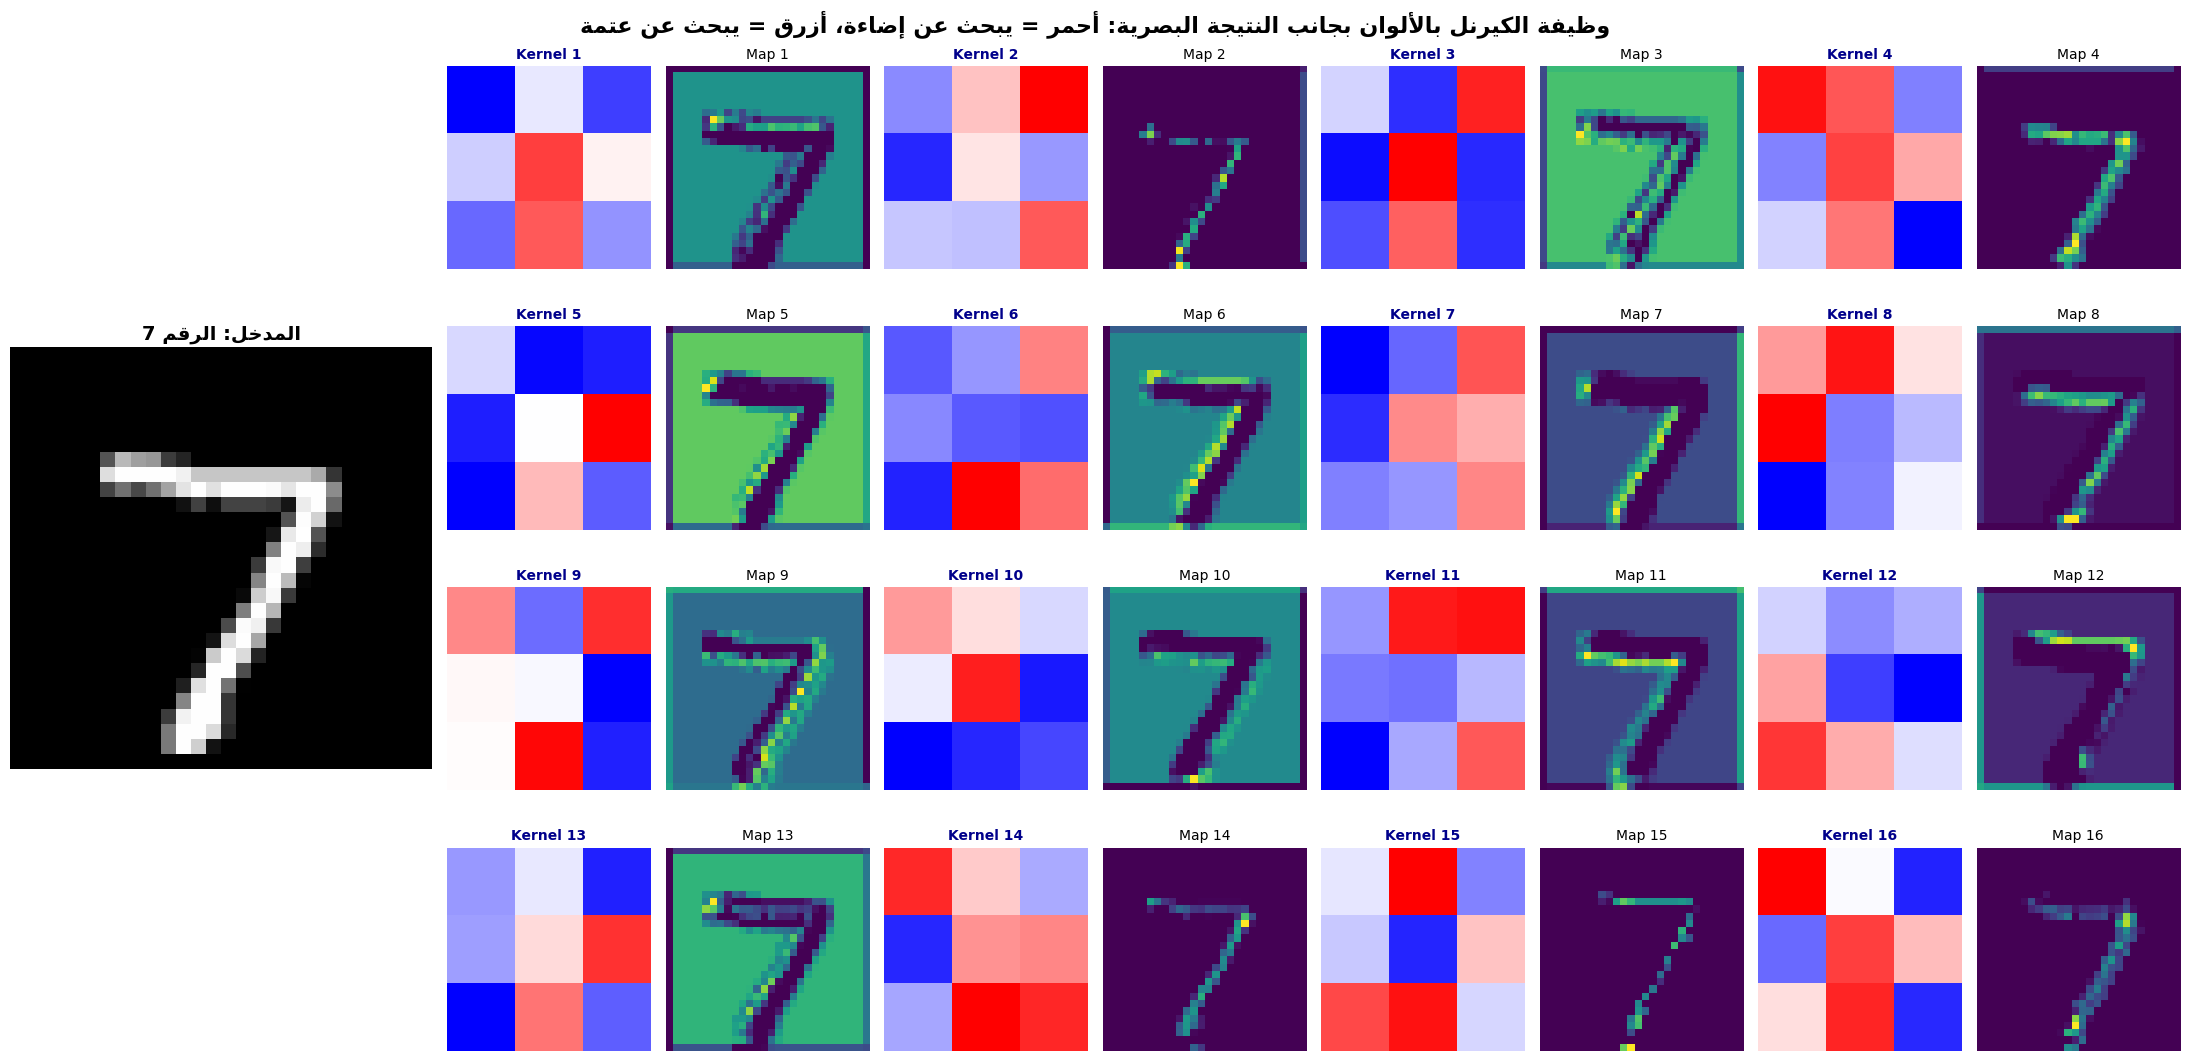

💡 كيف تقرأ الألوان لمحاذاة وظيفة الكيرنل (Kernel) مع النتيجة (Map):
   - إذا رأيت كيرنل ينقسم عمودياً إلى (أحمر على اليمين وأزرق على اليسار)، فهو يبحث عن حافة عمودية يمنى.
   - ستلاحظ فوراً أن خريطة الميزات (Map) المجاورة له تُضيء فقط عند الحواف المطابقة لهذا النمط الحسي!


In [31]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. Take a single image from the test set
sample_img, sample_label = test_dataset[0]

# 2. Forward pass through the first conv layer + ReLU
with torch.no_grad():
    feature_maps = torch.relu(cnn_model[0](sample_img.unsqueeze(0)))[0]  # Shape: (16, 28, 28)

# 3. Extract the weights of the 16 filters
# Shape: (16, 1, 3, 3)
filters = cnn_model[0].weight.detach().cpu().numpy()

# 4. Set up a balanced 4x10 grid (Columns 0 to 9)
fig = plt.figure(figsize=(22, 11))

# Original image on the far left (takes up columns 0 and 1)
ax0 = plt.subplot2grid((4, 10), (1, 0), rowspan=2, colspan=2)
ax0.imshow(sample_img[0], cmap='gray')
ax0.set_title(ar(f'المدخل: الرقم {sample_label}'), fontsize=14, weight='bold')
ax0.axis('off')

# Plot the 16 pairs
for k in range(16):
    row = k // 4
    col_group = 2 + (k % 4) * 2  # Columns: 2, 4, 6, 8 (each pair takes 2 slots: col and col+1)

    # --- Left: Plot the 3x3 filter as a colorful pattern ---
    ax_filt = plt.subplot2grid((4, 10), (row, col_group))

    # Find the largest absolute value in this specific filter to balance the colors perfectly around 0
    vmax = max(abs(filters[k, 0].min()), abs(filters[k, 0].max()))

    # 'bwr' map: Blue = Negative, White = Zero, Red = Positive
    ax_filt.imshow(filters[k, 0], cmap='bwr', vmin=-vmax, vmax=vmax)
    ax_filt.set_title(f'Kernel {k+1}', fontsize=10, weight='bold', color='darkblue')
    ax_filt.axis('off')

    # --- Right: Plot the resulting Feature Map ---
    ax_map = plt.subplot2grid((4, 10), (row, col_group + 1))
    ax_map.imshow(feature_maps[k].cpu(), cmap='viridis')
    ax_map.set_title(f'Map {k+1}', fontsize=10)
    ax_map.axis('off')

plt.suptitle(ar('وظيفة الكيرنل بالألوان بجانب النتيجة البصرية: أحمر = يبحث عن إضاءة، أزرق = يبحث عن عتمة'), fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

print("💡 كيف تقرأ الألوان لمحاذاة وظيفة الكيرنل (Kernel) مع النتيجة (Map):")
print("   - إذا رأيت كيرنل ينقسم عمودياً إلى (أحمر على اليمين وأزرق على اليسار)، فهو يبحث عن حافة عمودية يمنى.")
print("   - ستلاحظ فوراً أن خريطة الميزات (Map) المجاورة له تُضيء فقط عند الحواف المطابقة لهذا النمط الحسي!")

<div dir="rtl">

## 📝 تمارين

1. **كيرنلات أكثر:** غيّروا الطبقة الأولى إلى 32 كيرنل بدل 16. هل تتحسن الدقة؟ كم زاد عدد الأوزان؟
2. **بدون Pooling:** احذفوا طبقتَي `MaxPool2d`. احسبوا أولاً على الورق: كم سيصبح حجم مدخل `Linear`؟ (تلميح: عدّلوا `32 * 7 * 7`) ثم جرّبوا — ماذا حدث لعدد الأوزان وسرعة التدريب؟
3. **معدل التعلم:** جرّبوا `lr=0.1` ثم `lr=0.00001`. اربطوا ما ترونه برسم "الكرة في الوادي" من القسم 2.
4. **عودة للدارة:** ارسموا على الورق دارة المعادلة $f = (a + b) \cdot (b + 1)$ مع $a=2, b=3$ واحسبوا التدرجات يدوياً. (انتبهوا: $b$ يتفرع لبوابتين — التدرجات **تُجمع** عند التفرع!)
5. **تحدٍّ:** ابحثوا عن مجموعة بيانات **Fashion-MNIST** (ملابس بدل أرقام، نفس الأبعاد تماماً). غيّروا سطراً واحداً في تحميل البيانات ودرّبوا الشبكتين. أيهما تتأثر أكثر بصعوبة البيانات الجديدة، ولماذا؟

</div>

<div dir="rtl">

---
## 12. 📚 مصادر للاستزادة | Further Reading
</div>


- **Deep Learning Book** — Ian Goodfellow et al. (Chapter 9: Convolutional Networks)
- **CS231n** — Stanford Course on CNNs for Visual Recognition
- [**CS231n: Backpropagation, Intuitions**](https://cs231n.github.io/optimization-2/) — مصدر أمثلة "الدارة" في القسم الأول
- [**3Blue1Brown** — Neural Networks video series (YouTube)](https://www.youtube.com/c/3blue1brown)
- [Convolutional Neural Networks (CNNs) - Explained](https://www.youtube.com/watch?v=YGILT182T6w&t=82s)

---
*Computer Vision Course — Week 5*